In [ ]:
pip install pandas 

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectFromModel
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import geopandas as gpd
import folium
from shapely.geometry import box
from shapely.geometry import Polygon, Point
#import pandas_profiling

c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [2]:
# ...existing code...
import os

# 1) Ограничение через переменные среды (для MKL, OpenBLAS, OMP, NUMEXPR)
os.environ['OMP_NUM_THREADS'] = '4'         # OpenMP
os.environ['MKL_NUM_THREADS'] = '4'         # Intel MKL
os.environ['OPENBLAS_NUM_THREADS'] = '4'    # OpenBLAS
os.environ['NUMEXPR_NUM_THREADS'] = '4'     # numexpr

# 2) Python-уровень (если используете PyTorch / TensorFlow)
import torch
#torch.set_num_threads(4)
#torch.set_num_interop_threads(1)

import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(1)

# 3) Для sklearn / joblib / lightgbm указывайте n_jobs явно при создании моделей
# e.g. RandomForestRegressor(n_jobs=4), LGBMRegressor(n_jobs=4)
# ...existing code...

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#import missingno as msno # visualizing missing values
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for plot
%matplotlib inline
import torch 
import torch.nn as nn # For neural network building
import torch.nn.functional as F # For activation function
from torch.utils import data as torch_data  # alias to avoid clashing with pandas DataFrame named `data`
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler # Same as previous
from sklearn.model_selection import train_test_split # For splitting the data
from sklearn.model_selection import KFold # For kfold training

In [4]:
import openpyxl

In [16]:
#read df
df = pd.read_excel('in_01_FlatsData.xlsx',
dtype={'YEAR': 'Int64', 'LONGITUDE': float, 'LATITUDE': float, 'CITY': 'string', 'PRICE': float, 'ROOMS': 'Int64','TOTAL AREA': float,'FLOOR': 'Int64','TOTAL_FLOORS': 'Int64','KITCHEN_AREA': float,'RESIDENTIAL_COMPLEX': 'string','FURNITURE': 'string','CONDITION': 'string','CEILING': float,'URL': 'string','MATERIAL': 'string','REGION': 'string','STREET': 'string','CITY': 'string'},parse_dates=['PARSED_AT']
)

In [18]:
df25 = pd.read_excel('krisha_parsed16102025.xlsx')

In [20]:
df25.columns = ['PRICE', 'ROOMS', 'LONGITUDE', 'LATITUDE', 'SQUARE', 'FLOOR', 'ACCOM_FLOOR', 'KITCHEN', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 
                'CEILING', 'URL', 'MATERIAL', 'YEAR', 'PARSED_AT', 'REGION', 'STREET', 'CITY']

In [21]:
print(df.columns.tolist())

['PRICE', 'ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'KITCHEN_AREA', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'URL', 'MATERIAL', 'YEAR', 'PARSED_AT', 'REGION', 'STREET', 'CITY']


In [22]:
df25.columns = ['PRICE', 'ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'KITCHEN_AREA', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION',
 'CEILING', 'URL', 'MATERIAL', 'YEAR', 'PARSED_AT', 'REGION', 'STREET', 'CITY'               
]

In [23]:
print(df25.columns.tolist())

['PRICE', 'ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'KITCHEN_AREA', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'URL', 'MATERIAL', 'YEAR', 'PARSED_AT', 'REGION', 'STREET', 'CITY']


In [24]:
df1 = pd.concat([df, df25], axis = 0)
df1.shape

(589684, 19)

In [25]:
df1.isna().mean().mul(100).round(2).sort_values(ascending=False)

KITCHEN_AREA           44.07
ROOMS                   0.00
PRICE                   0.00
LONGITUDE               0.00
LATITUDE                0.00
FLOOR                   0.00
TOTAL AREA              0.00
TOTAL_FLOORS            0.00
RESIDENTIAL_COMPLEX     0.00
FURNITURE               0.00
CONDITION               0.00
CEILING                 0.00
URL                     0.00
MATERIAL                0.00
YEAR                    0.00
PARSED_AT               0.00
REGION                  0.00
STREET                  0.00
CITY                    0.00
dtype: float64

In [26]:
#drop unnecessary columns
del df1['KITCHEN_AREA']
del df1['PARSED_AT']
del df1['URL']
del df1['STREET']

In [27]:
df1.shape

(589684, 15)

In [28]:
df1['MATERIAL'].value_counts()

MATERIAL
кирпичный     227135
монолитный    202780
панельный     144153
иное           10251
иной            5365
Name: count, dtype: int64

In [29]:
df1['MATERIAL'] = df1['MATERIAL'].replace('иной', 'иное')

In [30]:
df1['REGION'].value_counts()

REGION
Kostanayskaya_obl_               48605
Bostandykskiy_r-n                44906
Karagandinskaya_obl_             44269
Aktyubinskaya_obl_               39281
Esilyskiy_r-n                    38068
Almaty_r-n                       33588
Mangistauskaya_obl_              26138
Almalinskiy_r-n                  21669
Pavlodarskaya_obl_               21253
Auezovskiy_r-n                   20955
Akmolinskaya_obl_                20325
Zapadno-Kazahstanskaya_obl_      18716
Vostochno-Kazahstanskaya_obl_    16632
Nura_r-n                         16465
Nauryzbayskiy_r-n                15366
Atyrauskaya_obl_                 15342
Saryarka_r-n                     14358
Zhambylskaya_obl_                12975
Medeuskiy_r-n                    12801
Alatauskiy_r-n                   12472
Almatinskaya_obl_                12078
Abay_obl_                         9432
Karatauskiy_r-n                   7482
Severo-Kazahstanskaya_obl_        7135
Turksibskiy_r-n                   6532
r-n_Baykonur      

In [31]:
df1['REGION'] = df1['REGION'].replace('Abay_obl_', 'Abayskaya_obl_')
df1['REGION'] = df1['REGION'].replace('Ulytau_obl_', 'Ulytauskaya_obl_')
df1['REGION'] = df1['REGION'].replace('Zhetysu_obl_', 'Zhetysuskaya_obl_')

In [32]:
df1.shape

(589684, 15)

In [33]:
#Проверка корректности координат (широта от -90 до 90, долгота от -180 до 180)
valid_coordinates = (df1['LATITUDE'].between(-90, 90) & df1['LONGITUDE'].between(-180, 180))
df1 = df1[valid_coordinates]

In [34]:
#find na percentage in df with one line of code:
print(df1.isna().mean() * 100)

PRICE                  0.0
ROOMS                  0.0
LONGITUDE              0.0
LATITUDE               0.0
TOTAL AREA             0.0
FLOOR                  0.0
TOTAL_FLOORS           0.0
RESIDENTIAL_COMPLEX    0.0
FURNITURE              0.0
CONDITION              0.0
CEILING                0.0
MATERIAL               0.0
YEAR                   0.0
REGION                 0.0
CITY                   0.0
dtype: float64


In [53]:
data = df1.copy()

In [54]:
#there are 3 columns than can be converted to numeric values stright away
print(data['FURNITURE'].unique())
print(data['CONDITION'].unique())
print(data['MATERIAL'].unique())

['полностью' 'без мебели' 'частично']
['хорошее' 'черновая отделка' 'требует ремонта' 'среднее'
 'свободная планировка' 'свежий ремонт' 'не новый, но аккуратный ремонт']
['монолитный' 'кирпичный' 'панельный' 'иное']


In [55]:
data.shape

(589684, 15)

In [56]:
# checking for min/max values of selected columns that contain  only number values
for col in data.columns:
    if data[col].dtype == 'Int64' or data[col].dtype == 'float64':
        print(col, data[col].min(), data[col].max())


PRICE 500000.0 26500000000.0
ROOMS 1 14
LONGITUDE -0.261859 166.85470834126
LATITUDE 5.2070046622841 68.681432
TOTAL AREA 20.1 843.0
FLOOR 1 42
TOTAL_FLOORS 1 316
CEILING 2.4 10.0
YEAR 1930 2030


In [57]:
data.dtypes

PRICE                  float64
ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE               object
CONDITION               object
CEILING                float64
MATERIAL                object
YEAR                     Int64
REGION                  object
CITY                    object
dtype: object

In [58]:
# the above numbers show that there may be errors in the data. Lets analyze each column separately
# YEAR
data[data['YEAR']> 2026]
data[data['YEAR'] > 2026].sort_values(by='YEAR')
future_year = data[data['YEAR'] > 2026]
#future_year.to_csv('out_err_future_year.csv', index=False)
future_year
#those positions require to be analyzed separately. The year of the building cannot be greater than the current year

,PRICE,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,MATERIAL,YEAR,REGION,CITY
80352,29000000.0,1,63.606633,53.237763,55.00,7,8,нет данных,без мебели,хорошее,3.0,кирпичный,2027,Kostanayskaya_obl_,Kostanay
90940,22258568.0,2,71.401095,51.104241,50.58,3,15,BUQAR JYRAU EXCLUSIVE,без мебели,свободная планировка,2.7,монолитный,2029,Esilyskiy_r-n,Astana
104379,18500000.0,2,77.247308,43.335719,44.00,1,4,нет данных,полностью,хорошее,3.0,кирпичный,2030,Almatinskaya_obl_,Talgar
113303,19500000.0,1,63.691560,53.249160,42.40,3,9,нет данных,полностью,хорошее,2.7,кирпичный,2028,Kostanayskaya_obl_,Kostanay
124446,3700000.0,1,69.804134,42.217426,24.00,2,2,нет данных,без мебели,требует ремонта,2.7,кирпичный,2030,Enbekshinskiy_r-n,Shymkent
234178,29000000.0,1,63.606633,53.237763,55.00,7,8,нет данных,без мебели,свежий ремонт,3.0,кирпичный,2027,Kostanayskaya_obl_,Kostanay
260508,17500000.0,2,71.346400,51.176118,56.00,4,17,нет данных,без мебели,черновая отделка,2.7,монолитный,2027,Saryarka_r-n,Astana
353983,20000000.0,1,73.170668,49.786367,51.50,3,5,нет данных,без мебели,черновая отделка,3.1,кирпичный,2027,Karagandinskaya_obl_,Karaganda
397448,16000000.0,2,69.580340,42.316694,42.50,4,5,нет данных,без мебели,"не новый, но аккуратный ремонт",2.8,кирпичный,2030,Turan_r-n,Shymkent
44871,33696000.0,3,63.602235,53.247437,93.60,5,5,Favorit,без мебели,черновая отделка,2.7,кирпичный,2027,Kostanayskaya_obl_,Kostanay


In [59]:
data1 = data[data['YEAR']<=2026]

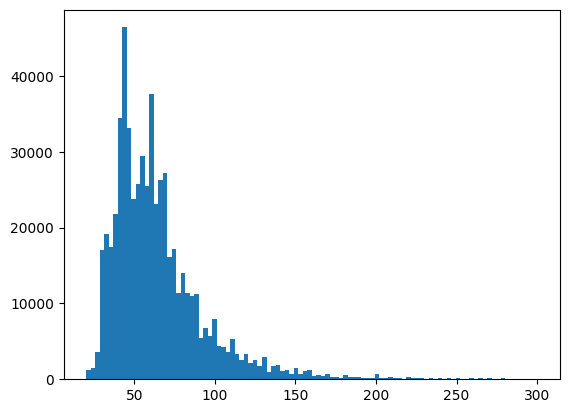

In [50]:
# TOTAL AREA. First show the distribution by total area
plt.hist(data['TOTAL AREA'], bins=100)
plt.show()

In [51]:
#data['TOTAL AREA'] = np.where(data['TOTAL AREA'] > 300, data['TOTAL AREA'].mean(), data['TOTAL AREA'])

In [61]:
data1['TOTAL AREA'].describe()

count    589667.000000
mean         65.436563
std          33.251081
min          20.100000
25%          44.960000
50%          58.800000
75%          75.300000
max         843.000000
Name: TOTAL AREA, dtype: float64

In [62]:
data1 = data1[data1['TOTAL AREA'] <= 300]
data1.shape

(588699, 15)

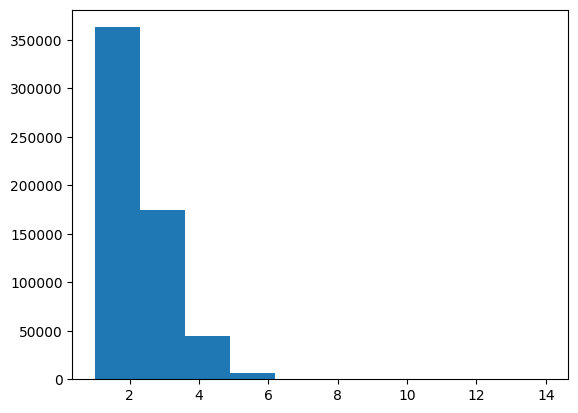

In [63]:
# ROOMS. First show the distribution by number of rooms
plt.hist(data['ROOMS'], bins=10)
plt.show()

In [64]:
data1 = data1[data1['ROOMS'] <= 6]
data1.shape

(588409, 15)

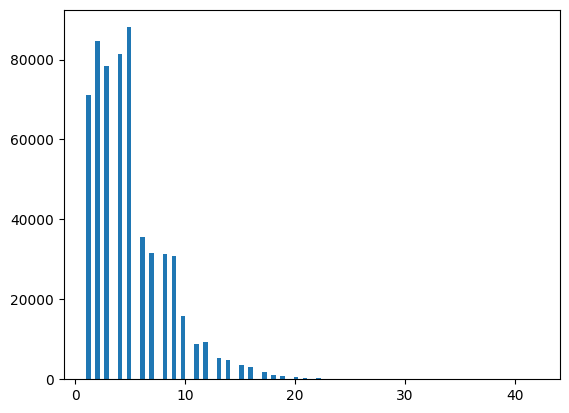

In [65]:
# next column to be analyzed is FLOOR
# FLOOR. First show the distribution by floor
plt.hist(data['FLOOR'], bins=100)
plt.show()

In [66]:
# sort the dataset by the floor in descednding order
data.sort_values(by='FLOOR', ascending=False)
# it looks correct. The highest floor lower than total floors in Astana

,PRICE,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,MATERIAL,YEAR,REGION,CITY
260535,52000000.0,3,71.419821,51.162058,133.1,42,43,Grand Alatau,частично,"не новый, но аккуратный ремонт",3.0,монолитный,2010,Saryarka_r-n,Astana
102852,100000000.0,4,71.421769,51.128388,200.0,41,42,Северное сияние,без мебели,свежий ремонт,3.0,монолитный,2005,Esilyskiy_r-n,Astana
391644,78000000.0,4,71.420063,51.162483,151.0,41,42,нет данных,полностью,свежий ремонт,3.0,монолитный,2010,Saryarka_r-n,Astana
318800,100000000.0,4,71.421769,51.128388,200.0,41,42,Северное сияние,без мебели,свежий ремонт,3.0,монолитный,2005,Esilyskiy_r-n,Astana
103045,78000000.0,4,71.420063,51.162483,151.0,41,42,нет данных,полностью,свежий ремонт,3.0,монолитный,2010,Saryarka_r-n,Astana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166653,47000000.0,3,76.856505,43.234759,72.0,1,5,нет данных,частично,"не новый, но аккуратный ремонт",2.6,панельный,1987,Auezovskiy_r-n,Almaty
55,21500000.0,2,71.385468,51.170299,53.0,1,9,нет данных,частично,хорошее,2.7,кирпичный,2010,Saryarka_r-n,Astana
77,21000000.0,2,71.383959,51.175184,55.0,1,6,нет данных,полностью,хорошее,2.7,кирпичный,2011,Saryarka_r-n,Astana
71,26500000.0,2,71.459864,51.147707,60.0,1,9,Соло,полностью,хорошее,2.7,кирпичный,2008,Almaty_r-n,Astana


(array([5.47920e+04, 2.38630e+05, 1.73148e+05, 5.48910e+04, 3.63380e+04,
        1.74100e+04, 1.05890e+04, 2.99700e+03, 1.73000e+02, 1.93000e+02,
        1.88000e+02, 1.58000e+02, 5.30000e+01, 7.90000e+01, 3.00000e+00,
        0.00000e+00, 4.00000e+00, 1.70000e+01, 1.00000e+00, 0.00000e+00,
        2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        2.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 2.00000e+00, 0.00000e+00, 2.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00

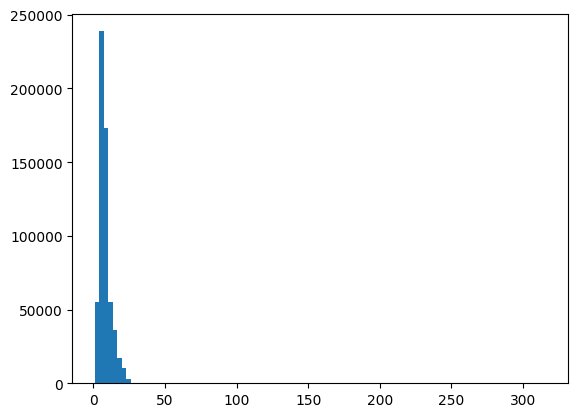

In [67]:
# the next variable to be analyzed is TOTAL_FLOORS
# First show the distribution by total floors
plt.hist(data['TOTAL_FLOORS'], bins=100)
#plt.show()

In [68]:
data1 = data1[data1['TOTAL_FLOORS'] <= 50]
data1.shape

(588367, 15)

In [69]:
# lets check the longitude and latitude values
# what is the minimal longitude and latitude values for Kazakshtan
print(data['LONGITUDE'].min(), data['LATITUDE'].min())
print(data['LONGITUDE'].max(), data['LATITUDE'].max())

-0.261859 5.2070046622841
166.85470834126 68.681432


In [70]:
# Kazakhstan coordinates
kazakhstan_coordinates = {
    'min_longitude': 46.5,
    'max_longitude': 87.3,
    'min_latitude': 40.6,
    'max_latitude': 55.4
}

print("Kazakhstan Coordinates:")
print(f"Longitude: {kazakhstan_coordinates['min_longitude']} to {kazakhstan_coordinates['max_longitude']}")
print(f"Latitude: {kazakhstan_coordinates['min_latitude']} to {kazakhstan_coordinates['max_latitude']}")

Kazakhstan Coordinates:
Longitude: 46.5 to 87.3
Latitude: 40.6 to 55.4


In [71]:
# find the rows with the longitude and latitude values outside of Kazakhstan
outside_kazakhstan = data[(data['LONGITUDE'] < kazakhstan_coordinates['min_longitude']) | (data['LONGITUDE'] > kazakhstan_coordinates['max_longitude']) | (data['LATITUDE'] < kazakhstan_coordinates['min_latitude']) | (data['LATITUDE'] > kazakhstan_coordinates['max_latitude'])]
#outside_kazakhstan.to_csv('out_err_ouside_kazakhstan.csv', index=False)
outside_kazakhstan
# conclusion: all the locations are shown in Kazakhstan but longitude latitude mean that longitude and latitude values are not correct

,PRICE,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,MATERIAL,YEAR,REGION,CITY
2047,40500000.0,2,118.558989,48.059751,44.00,12,12,Акварель,частично,хорошее,2.74,монолитный,2017,Bostandykskiy_r-n,Almaty
32169,9200000.0,2,37.220804,55.611795,55.00,3,3,нет данных,полностью,хорошее,2.70,кирпичный,1986,Mangistauskaya_obl_,Mangyshlak
60982,30000000.0,2,37.395194,55.544158,64.00,7,9,нет данных,частично,хорошее,2.80,монолитный,2016,Turksibskiy_r-n,Almaty
77165,14000000.0,3,53.146928,56.837785,56.30,4,5,нет данных,без мебели,требует ремонта,2.70,панельный,1986,Almatinskaya_obl_,Zarechnoe
85918,6000000.0,1,55.431588,25.218259,30.00,1,4,нет данных,частично,хорошее,3.00,кирпичный,1990,Mangistauskaya_obl_,Zhanaozen
127254,40000000.0,2,-0.261859,43.177701,51.80,8,9,нет данных,частично,среднее,3.00,панельный,1989,Auezovskiy_r-n,Almaty
132248,11000000.0,2,53.129160,56.825690,36.00,2,2,нет данных,полностью,среднее,2.60,кирпичный,1971,Almatinskaya_obl_,Zarechnoe
133932,10965000.0,1,40.906359,51.146263,49.56,7,7,ZERE,без мебели,черновая отделка,3.00,кирпичный,2024,Aktyubinskaya_obl_,Aktobe
140706,10000000.0,2,55.302310,25.274515,55.90,4,5,нет данных,без мебели,среднее,3.00,кирпичный,1990,Mangistauskaya_obl_,Aktau
143789,10200000.0,1,55.309317,25.278395,42.70,6,7,нет данных,без мебели,требует ремонта,3.20,монолитный,2024,Mangistauskaya_obl_,Aktau


In [72]:
data1 = data1[~data1.index.isin(outside_kazakhstan.index)]

In [73]:
# show the descriptive statistics of the dataset
data1.describe().T
# this way gives the statistics only for the numeric columns

,count,mean,std,min,25%,50%,75%,max
PRICE,588300.0,31650646.166288,53686382.655203,500000.0,16500000.0,24000000.0,36000000.0,26500000000.0
ROOMS,588300.0,2.251977,0.934396,1.0,2.0,2.0,3.0,6.0
LONGITUDE,588300.0,69.899354,8.516749,47.12465,63.699788,71.451771,76.876317,85.61065
LATITUDE,588300.0,48.041219,4.002112,40.661816,43.259326,49.946307,51.143912,55.293831
TOTAL AREA,588300.0,64.821437,30.126447,20.1,44.9,58.7,75.0,300.0
FLOOR,588300.0,4.953197,3.462923,1.0,2.0,4.0,7.0,42.0
TOTAL_FLOORS,588300.0,8.279487,4.358859,1.0,5.0,8.0,10.0,48.0
CEILING,588300.0,2.768942,0.206223,2.4,2.7,2.7,3.0,10.0
YEAR,588300.0,2002.128516,20.71211,1930.0,1984.0,2012.0,2020.0,2026.0


In [74]:
# show how many cities are represented in dataset and sort in the dewcending order
data1['CITY'].value_counts().sort_values(ascending=False)

CITY
Almaty        139351
Astana        109644
Kostanay       42905
Aktobe         38216
Karaganda      31933
               ...  
Baykent            1
Kosozen            1
Maloubinka         1
Kabanbay           1
Sastobe            1
Name: count, Length: 437, dtype: int64

In [75]:
# show averaga price per city
aver_prices_by_city=data1.groupby('CITY')['PRICE'].mean().sort_values(ascending=False)
aver_prices_by_city

CITY
Zhanaturmys     8.750000e+07
Galitskoe       7.000000e+07
Almaty          5.320223e+07
Andas_batyra    4.976250e+07
Almaly          4.450000e+07
                    ...     
Karaturuk       1.999999e+06
Matay           1.800000e+06
Volynyy         1.250000e+06
Arykbalyk       1.000000e+06
Pervomayskiy    6.000000e+05
Name: PRICE, Length: 437, dtype: float64

In [76]:
# find which cities in total constitute 95% of the dataset and show them
cities = data1['CITY'].value_counts()
cities_95 = cities[cities.cumsum() < 0.95*cities.sum()]
cities_95
# 85% of the dataset is represented by 12 cities

CITY
Almaty              139351
Astana              109644
Kostanay             42905
Aktobe               38216
Karaganda            31933
Aktau                24284
Shymkent             22641
Uralysk              17608
Pavlodar             15811
Atyrau               14873
Kokshetau            14482
Usty-Kamenogorsk     14267
Semey                12801
Taraz                12513
Taldykorgan           7976
Temirtau              7597
Petropavlovsk         6984
Kyzylorda             3970
Rudnyy                3802
ekibastuz             3406
Zhezkazgan            3364
Besagash              3106
Kosshy                2945
Balhash               1972
Satpaev               1946
Name: count, dtype: int64

In [77]:
# encode the city column in the way that the cities that constitute 85% of the dataset are identified indivually in the way city: 
# number in the  dictionary and the rest are encoded in the dictionary as 'Other' and assigned the last number
# Create a dictionary with cities as keys and their positions in the sorted cities_85 as values
cities_95_dict = {city: idx + 1 for idx, city in enumerate(cities_95.index)}
cities_95_dict['Other'] = len(cities_95_dict) + 1

In [78]:
# Encode the CITY column using the created dictionary
data1['CITY_CAT'] = data1['CITY'].map(cities_95_dict).fillna(cities_95_dict['Other'])
print(cities_95_dict)
data1

{'Almaty': 1, 'Astana': 2, 'Kostanay': 3, 'Aktobe': 4, 'Karaganda': 5, 'Aktau': 6, 'Shymkent': 7, 'Uralysk': 8, 'Pavlodar': 9, 'Atyrau': 10, 'Kokshetau': 11, 'Usty-Kamenogorsk': 12, 'Semey': 13, 'Taraz': 14, 'Taldykorgan': 15, 'Temirtau': 16, 'Petropavlovsk': 17, 'Kyzylorda': 18, 'Rudnyy': 19, 'ekibastuz': 20, 'Zhezkazgan': 21, 'Besagash': 22, 'Kosshy': 23, 'Balhash': 24, 'Satpaev': 25, 'Other': 26}


,PRICE,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,MATERIAL,YEAR,REGION,CITY,CITY_CAT
0,70000000.0,3,76.893760,43.237206,90.4,6,18,Оркендеу,полностью,хорошее,3.0,монолитный,2017,Bostandykskiy_r-n,Almaty,1.0
1,13000000.0,1,71.555289,51.131212,36.0,6,9,нет данных,без мебели,хорошее,2.7,кирпичный,2017,Almaty_r-n,Astana,2.0
2,98500000.0,3,76.890746,43.199999,115.0,23,25,Mega Tower Almaty,без мебели,хорошее,2.8,монолитный,2015,Bostandykskiy_r-n,Almaty,1.0
3,11000000.0,1,71.540958,51.108916,38.0,2,10,нет данных,без мебели,черновая отделка,2.8,монолитный,2022,Almaty_r-n,Astana,2.0
4,135000000.0,3,76.895794,43.197429,138.0,10,16,ATRIA,без мебели,хорошее,3.0,монолитный,2021,Bostandykskiy_r-n,Almaty,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166673,69000000.0,2,76.946928,43.230898,59.0,20,33,нет данных,без мебели,черновая отделка,3.0,монолитный,2019,Bostandykskiy_r-n,Almaty,1.0
166674,37000000.0,2,76.810091,43.241340,66.0,6,9,Аккент,полностью,свежий ремонт,2.6,монолитный,2010,Alatauskiy_r-n,Almaty,1.0
166675,34500000.0,2,76.964968,43.222909,30.3,1,4,нет данных,частично,свежий ремонт,2.7,кирпичный,1967,Medeuskiy_r-n,Almaty,1.0
166676,80000000.0,3,76.964500,43.221451,75.0,7,9,нет данных,полностью,свежий ремонт,2.8,панельный,1991,Medeuskiy_r-n,Almaty,1.0


In [79]:
col = 'REGION' 
vc = data1[col].value_counts(dropna=False)
print("unique values:", len(vc))

unique values: 36


In [80]:
assert len(vc) == 36, f"expected 36 unique values but got {len(vc)}"
mapping = {k: idx + 1 for idx, (k, _) in enumerate(vc.items())}
# create new integer column (preserve NA as a special code if present)
data1[f"{col}_int"] = data1[col].map(mapping).astype("Int64")
# optional: replace original column
# data[col] = data[col].map(mapping).astype("Int64")

In [81]:
data1.dtypes

PRICE                  float64
ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE               object
CONDITION               object
CEILING                float64
MATERIAL                object
YEAR                     Int64
REGION                  object
CITY                    object
CITY_CAT               float64
REGION_int               Int64
dtype: object

In [110]:
#col = 'RESIDENTIAL_COMPLEX_new' 
#vc = data1[col].value_counts(dropna=False)
#print("unique values:", len(vc))

unique values: 2022


In [64]:
#assert len(vc) == 2022, f"expected 2022 unique values but got {len(vc)}"
#mapping = {k: idx + 1 for idx, (k, _) in enumerate(vc.items())}

# create new integer column (preserve NA as a special code if present)
#data1[f"{col}_int"] = data1[col].map(mapping).astype("Int64")

In [56]:
data1.dtypes

PRICE                  float64
ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE               object
CONDITION               object
CEILING                float64
MATERIAL                object
YEAR                     Int64
REGION                  object
CITY                    object
CITY_CAT               float64
REGION_int               Int64
dtype: object

In [82]:
X = data1.copy()
y = X['PRICE']
X.drop(columns=['PRICE'], inplace=True) 

In [58]:
import scipy.stats as ss  # import scipy.stats module as alias 'ss' for statistical tests like chi2_contingency
# Cramér's V for categorical vs categorical association (with bias correction)
def cramers_v(x, y):
    # build contingency table between two categorical series, replace NaN with string "NA"
    conf = pd.crosstab(x.fillna("NA"), y.fillna("NA"))
    # compute chi-squared statistic from contingency table (returns tuple, take statistic at index 0)
    chi2 = ss.chi2_contingency(conf, correction=False)[0]
    # total number of observations used in the contingency table
    n = conf.sum().sum()
    # phi-squared statistic (chi2 normalized by n)
    phi2 = chi2 / n
    # number of rows (r) and columns (k) in contingency table
    r, k = conf.shape
    # apply bias correction to phi2 (Bergsma & Wicher correction)
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    # corrected effective number of rows
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    # corrected effective number of columns
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    # denominator for Cramér's V (use the smaller dimension minus 1)
    denom = min(kcorr - 1, rcorr - 1)
    # return square root of corrected phi2 divided by denom if denom positive, else 0.0
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0
# Correlation ratio (eta) for categorical -> numeric association
def correlation_ratio(categories, values):
    # factorize categories to integer labels; treat NaN as "NA"
    cat, labels = pd.factorize(categories.fillna("NA"))
    # ensure values are float numpy array
    values = np.asarray(values, dtype=float)
    # compute overall mean of the numeric values
    grand_mean = values.mean()
    # initialize between-group sum of squares
    ss_between = 0.0
    # compute total sum of squares (denominator for eta)
    ss_total = ((values - grand_mean) ** 2).sum()
    # iterate over each unique category code
    for c in np.unique(cat):
        # boolean mask selecting rows for current category
        mask = cat == c
        # number of observations in this category
        n_c = mask.sum()
        # skip empty categories (shouldn't happen but be safe)
        if n_c == 0:
            continue
        # mean of values in this category
        mean_c = values[mask].mean()
        # accumulate weighted squared deviation of category mean from grand mean
        ss_between += n_c * (mean_c - grand_mean) ** 2
    # eta-squared is fraction of variance explained by categories; guard divide-by-zero
    eta2 = ss_between / ss_total if ss_total > 0 else 0.0
    # return eta (square root of eta-squared)
    return np.sqrt(eta2)
# Rank features using appropriate measure depending on feature dtype
def rank_features(X, y, topn=30):
    results = []  # list to collect (feature, score, method) tuples
    for col in X.columns:  # loop over each column name in X
        # if column is numeric use Pearson correlation
        if pd.api.types.is_numeric_dtype(X[col]):
            # convert column to float, fill NaN with 0, extract numpy array
            a = X[col].astype(float).fillna(0).values
            # convert target to float, fill NaN with target mean, extract numpy array
            b = y.astype(float).fillna(y.mean()).values
            # if either array has zero std dev then correlation undefined -> set score 0
            if np.std(a) == 0 or np.std(b) == 0:
                score = 0.0
            else:
                # compute absolute Pearson correlation coefficient
                score = abs(np.corrcoef(a, b)[0, 1])
            kind = 'numeric-pearson'  # label the method used
        else:
            # for non-numeric (categorical) features compute correlation ratio (eta)
            score = correlation_ratio(X[col], y)
            kind = 'categorical-eta'  # label the method used
        # append tuple with feature name, score and method to results
        results.append((col, score, kind))
    # build dataframe from results and sort by score descending
    df_res = pd.DataFrame(results, columns=['feature', 'score', 'method']).sort_values('score', ascending=False)
    # return top-n rows
    return df_res.head(topn)

# usage
corr_numeric = rank_features(X, y, topn=50)
print(corr_numeric)

                feature     score           method
6   RESIDENTIAL_COMPLEX  0.418421  categorical-eta
3            TOTAL AREA  0.392410  numeric-pearson
12               REGION  0.300713  categorical-eta
0                 ROOMS  0.248332  numeric-pearson
13                 CITY  0.247568  categorical-eta
9               CEILING  0.212869  numeric-pearson
10             MATERIAL  0.204210  categorical-eta
14             CITY_CAT  0.168005  numeric-pearson
5          TOTAL_FLOORS  0.167717  numeric-pearson
11                 YEAR  0.157335  numeric-pearson
2              LATITUDE  0.145075  numeric-pearson
4                 FLOOR  0.109498  numeric-pearson
1             LONGITUDE  0.108544  numeric-pearson
8             CONDITION  0.081563  categorical-eta
7             FURNITURE  0.072681  categorical-eta
15           REGION_int  0.050702  numeric-pearson


In [59]:
# Correlation ranking (numeric: Pearson, categorical: correlation ratio eta)
# use the previously defined rank_features(...) which selects Pearson for numerics and eta for categoricals
df_scores = rank_features(X, y, topn=X.shape[1])            # rank all features
print(df_scores.head(30))                                   # show top 30 by absolute association
# Keep features with association score > 0.03
keep = df_scores.loc[df_scores['score'] > 0.03, 'feature'].tolist()
print(f"Kept {len(keep)} features (score > 0.03)")

                feature     score           method
6   RESIDENTIAL_COMPLEX  0.418421  categorical-eta
3            TOTAL AREA  0.392410  numeric-pearson
12               REGION  0.300713  categorical-eta
0                 ROOMS  0.248332  numeric-pearson
13                 CITY  0.247568  categorical-eta
9               CEILING  0.212869  numeric-pearson
10             MATERIAL  0.204210  categorical-eta
14             CITY_CAT  0.168005  numeric-pearson
5          TOTAL_FLOORS  0.167717  numeric-pearson
11                 YEAR  0.157335  numeric-pearson
2              LATITUDE  0.145075  numeric-pearson
4                 FLOOR  0.109498  numeric-pearson
1             LONGITUDE  0.108544  numeric-pearson
8             CONDITION  0.081563  categorical-eta
7             FURNITURE  0.072681  categorical-eta
15           REGION_int  0.050702  numeric-pearson
Kept 16 features (score > 0.03)


In [136]:
# VIF - iterative removal of multicollinear features (optimized)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
def compute_vif_df(df):
    """Return pd.Series of VIF for each column in df (df must be numeric and have no NaNs)."""
    Xc = sm.add_constant(df, has_constant='add')
    try:
        vifs = [variance_inflation_factor(Xc.values, i+1)  # skip constant at index 0
                for i in range(df.shape[1])]
    except Exception as e:
        # fallback: return large VIFs if computation fails
        vifs = [float('inf')] * df.shape[1]
    return pd.Series(vifs, index=df.columns)

def remove_high_vif(X, thresh=10.0, max_iter=50, verbose=True):
    # keep only numeric columns for VIF calculation
    X_num = X.select_dtypes(include=[np.number]).copy()
    if X_num.shape[1] == 0:
        if verbose: print("No numeric columns to compute VIF on.")
        return [], pd.Series(dtype=float)
    # fill missing and cast to float
    X_num = X_num.fillna(0).astype(float)
    kept = list(X_num.columns)
    it = 0
    while it < max_iter:
        it += 1
        vif_series = compute_vif_df(X_num[kept])
        if verbose:
            print(f"Iteration {it} - max VIF {vif_series.max():.3f}")
        max_vif = vif_series.max()
        if max_vif <= thresh or len(kept) <= 1:
            break
        # drop feature with highest VIF
        drop_feat = vif_series.idxmax()
        kept.remove(drop_feat)
        if verbose:
            print(f"  Dropping '{drop_feat}' (VIF={max_vif:.3f})")
    final_vif = compute_vif_df(X_num[kept])
    if verbose:
        print("Final VIF (top 20):")
        print(final_vif.sort_values(ascending=False).head(20))
    return kept, final_vif
# usage: adjust threshold as needed (e.g. 10)
kept_features, final_vif = remove_high_vif(X, thresh=10.0, max_iter=100, verbose=True)

# optionally restrict X to kept features for downstream modelling
#X = X[kept_features]
#print(f"X now has {X.shape[1]} features after VIF filtering")

Iteration 1 - max VIF 3.429
Final VIF (top 20):
TOTAL AREA                     3.428982
ROOMS                          2.990812
TOTAL_FLOORS                   2.329924
YEAR                           1.969338
FLOOR                          1.782714
CEILING                        1.648546
LATITUDE                       1.418890
CITY_CAT                       1.402106
REGION_int                     1.394453
RESIDENTIAL_COMPLEX_new_int    1.198239
LONGITUDE                      1.175638
dtype: float64


In [60]:
#del data1['RESIDENTIAL_COMPLEX']
#del data1['RESIDENTIAL_COMPLEX_new']
#del data1['RESIDENTIAL_COMPLEX_REGION']

In [130]:
#del data1['CITY_new']

In [83]:
#del data1['RESIDENTIAL_COMPLEX_REGION_new']
#del data1['RESIDENTIAL_COMPLEX_new_int']
del data1['CITY']
del data1['REGION_int']
#del data1['REGION']

In [84]:
data1.dtypes

PRICE                  float64
ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE               object
CONDITION               object
CEILING                float64
MATERIAL                object
YEAR                     Int64
REGION                  object
CITY_CAT               float64
dtype: object

In [85]:
data1.shape

(588300, 15)

In [ ]:
# For categorical vs categorical pairs (if needed), compute Cramér's V:
#cv = cramers_v(data['RESIDENTIAL_COMPLEX_REGION'], data['RESIDENTIAL_COMPLEX_REGION_new'])
#print(cv)
# Option: for high-cardinality categoricals try frequency or target encoding first,
# or one-hot and compute Pearson on dummies:
# dummies = pd.get_dummies(X.select_dtypes(exclude=[np.number]).astype(str), dummy_na=True)
# dummies_corr = dummies.apply(lambda c: abs(np.corrcoef(c.fillna(0), y.fillna(y.mean()))[0,1]))
# print(dummies_corr.sort_values(ascending=False).head(30))

0.9978578765547479


In [118]:
# Tree-based quick check / permutation importance
# ...existing code...
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.inspection import permutation_importance
#rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1).fit(X.fillna(0), y)
#imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
#print(imp.head(30))
#perm = permutation_importance(rf, X.fillna(0), y, n_repeats=10, random_state=0, n_jobs=-1)
#perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
#print(perm_imp.head(30))
# ...existing code...

In [139]:
# Univariate selection (f_regression + mutual info)
# ...existing code...
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
skb_f = SelectKBest(f_regression, k=30).fit(X.fillna(0), y)   # adjust k
skb_mi = SelectKBest(mutual_info_regression, k=30).fit(X.fillna(0), y)
print("Top f_reg:", X.columns[skb_f.get_support()])
print("Top mi:",   X.columns[skb_mi.get_support()])
# ...existing code...

ValueError: k should be <= n_features = 17; got 30. Use k='all' to return all features.

In [16]:
# Lasso for selection (scale features first)
# ...existing code...
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
sc = StandardScaler()
X_s = sc.fit_transform(X.fillna(0))
lasso = LassoCV(cv=5, n_jobs=-1, random_state=0).fit(X_s, y)
selected = X.columns[lasso.coef_ != 0].tolist()
print("Lasso selected:", selected)
# ...existing code...


Lasso selected: ['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'TOTAL_FLOORS', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'CITY_CAT']


In [140]:
data1.dtypes

PRICE           float64
ROOMS             Int64
LONGITUDE       float64
LATITUDE        float64
TOTAL AREA      float64
FLOOR             Int64
TOTAL_FLOORS      Int64
FURNITURE        object
CONDITION        object
CEILING         float64
MATERIAL         object
YEAR              Int64
CITY_CAT        float64
dtype: object

In [86]:
print(data1.columns.tolist())

['PRICE', 'ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'REGION', 'CITY_CAT']


In [142]:
#data['REGION'] = data['REGION'].astype(str)
#data['CITY_new'] = data['CITY_new'].astype(str)
#data['RESIDENTIAL_COMPLEX_REGION_new'] = data['RESIDENTIAL_COMPLEX_REGION_new'].astype(str)
#data['RESIDENTIAL_COMPLEX_new1'] = data['RESIDENTIAL_COMPLEX_new1'].astype(str)

In [87]:
data1.dtypes

PRICE                  float64
ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE               object
CONDITION               object
CEILING                float64
MATERIAL                object
YEAR                     Int64
REGION                  object
CITY_CAT               float64
dtype: object

In [88]:
data1['FURNITURE'] = data1['FURNITURE'].astype('str')
data1['CONDITION'] = data1['CONDITION'].astype('str')
data1['MATERIAL'] = data1['MATERIAL'].astype('str')

In [89]:
data2 = data1.copy()

In [12]:
###model Romana:

In [30]:
#pip install --upgrade cryptography pyOpenSSL

In [5]:
# ...existing code...
import os
# suppress most TF logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # 0=all, 1=warning, 2=error, 3=fatal
# disable oneDNN custom ops (if you want identical numerics)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
# avoid pre-registering GPU plugins if you want to run CPU-only
# os.environ["CUDA_VISIBLE_DEVICES"] = ""   # uncomment to force CPU
# make TF grow GPU memory instead of preallocating (optional)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

# Restart kernel after adding this cell, then import libraries:
import tensorflow as tf
# ...existing code...

In [6]:
# Importing the libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [92]:
data1.dtypes

PRICE                  float64
ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE               object
CONDITION               object
CEILING                float64
MATERIAL                object
YEAR                     Int64
REGION                  object
CITY_CAT               float64
dtype: object

In [93]:
data1['PRICE_ln'] = np.log(data1['PRICE'])

In [94]:
del data1['PRICE']

In [95]:
data1['MATERIAL'].value_counts()

MATERIAL
кирпичный     226702
монолитный    201926
панельный     144098
иное           15574
Name: count, dtype: int64

In [96]:
data1['FURNITURE'] = np.where(data1['FURNITURE'] == 'без мебели', 1, 
                             np.where(data1['FURNITURE'] == 'частично', 2, 
                                      np.where(data1['FURNITURE'] == 'полностью', 3, 0)))

In [97]:
data1['CONDITION'] = np.where(data1['CONDITION'] == 'черновая отделка', 1,
                             np.where(data1['CONDITION'] == 'свободная планировка', 1,
                                      np.where(data1['CONDITION'] == 'требует ремонта', 2,
                                               np.where(data1['CONDITION'] == 'не новый, но аккуратный ремонт', 3,
                                                        np.where(data1['CONDITION'] == 'среднее', 3, 
                                                                 np.where(data1['CONDITION'] == 'хорошее', 4,
                                                                          np.where(data1['CONDITION'] == 'свежий ремонт', 5, 0)))))))    

In [98]:
data1['MATERIAL'] = np.where(data1['MATERIAL'] == 'иное', 1,
                            np.where(data1['MATERIAL'] == 'иной', 1,
                                     np.where(data1['MATERIAL'] == 'панельный', 2,
                                              np.where(data1['MATERIAL'] == 'монолитный', 3,
                                                       np.where(data1['MATERIAL'] == 'кирпичный', 4, 0)))))

In [99]:
data1.dtypes

ROOMS                    Int64
LONGITUDE              float64
LATITUDE               float64
TOTAL AREA             float64
FLOOR                    Int64
TOTAL_FLOORS             Int64
RESIDENTIAL_COMPLEX     object
FURNITURE                int64
CONDITION                int64
CEILING                float64
MATERIAL                 int64
YEAR                     Int64
REGION                  object
CITY_CAT               float64
PRICE_ln               float64
dtype: object

In [101]:
2+2

4

In [102]:
data1.to_pickle('House_prices_KZ_data_preprocessed_wt_outliers_Nov2025.pkl')

## Kazakhstan House Price Geo-Segmentation Workflow

This section adds a reproducible pipeline to: (1) convert statistical centroids Excel file to a shapefile (`stat.shp`), (2) enrich the national places polygons (`gis_osm_places_a_free_1.shp`) with socio‑economic indicators via spatial join & interpolation, and (3) derive large‑scale market segments (polygons) for downstream house price modeling.

### Data Inputs
- `gis_osm_places_a_free_1.shp`: Base administrative/place polygons (regions / populated places). Must be in WGS84 (EPSG:4326) or will be reprojected.
- `StatKZ092025.xlsx` (assumed name): Excel with centroid rows and columns:
  - `latitude`, `longitude`, `region`
  - Socio‑economic attributes (importance order):
    1. `srednmes_zarplata`
    2. `index_real_zarplaty`
    3. `chislennost_naseleniya_092025`
    4. `prirost_naselenya`
    5. `temp_prirosta_percent`
    6. `index_potreb_cen_tovary_uslugi`
    7. `index_potreb_cen_prodovolstv_tovary`
    8. `index_potreb_cen_neprodovolstv_tovary`
    9. `index_potreb_cen_platnye_uslugi`
- House price point dataframe (already loaded earlier in notebook or will be loaded) with `latitude`, `longitude` (WGS84) and pricing features.

### Method Overview
1. Install geospatial + clustering libraries (GeoPandas, PySAL, HDBSCAN, etc.).
2. Load Excel, validate columns, build GeoDataFrame of centroids; export as `stat.shp` for traceability.
3. Load `gis_osm_places_a_free_1.shp`, clean geometry, ensure CRS consistency (reproject to projected CRS for area/distance e.g. EPSG:3857 or Kazakhstan local equal-area if available).
4. Spatial join centroid points to polygons. For polygons without a centroid match, perform inverse distance weighting (IDW) from nearest k centroids to interpolate each missing attribute.
5. Attach socio‑economic attributes to polygons; persist enriched shapefile.
6. Compute house price point density per polygon (point-in-polygon count / polygon area) and add as auxiliary feature (optional for clustering but can guide selection / QA).
7. Build weighted feature matrix (attributes standardized). Apply weights according to provided importance order (higher importance => larger weight, e.g. descending geometric sequence or linear). Create composite features.
8. Spatially constrained clustering on polygons using PySAL `spopt` / `region` methods:
   - Construct Queen contiguity graph.
   - Run: (a) Ward hierarchical clustering with spatial constraint (AZP or SKATER) across candidate k (e.g. 4..12). Evaluate with pseudo-F (within vs between) & silhouette (feature space) while preserving contiguity.
   - Select k via elbow / max silhouette.
   - Dissolve polygons by cluster to create market segment polygons.
9. Alternative density-driven method (points): run HDBSCAN on scaled socio-economic attributes associated to each house price point (after assigning polygon attributes), then build alpha shape / convex hulls of clusters for comparison.
10. Assign final `segment_id` to house price points (spatial join). Export:
    - `segments_spatial_constrained.shp` (primary)
    - `segments_hdbscan.shp` (alternative)
    - `house_prices_with_segment.geojson`
11. Visualization & sanity checks (maps, attribute summaries per segment).

### Rationale for Methods
- Spatially constrained clustering (SKATER / AZP / Ward) is widely used in regionalization research (e.g., market area delineation) ensuring clusters are contiguous.
- HDBSCAN provides a modern density-based perspective capturing irregular shapes and variable density without pre-specifying k.
- IDW interpolation is a standard baseline for filling attribute gaps when centroids are sparse.

Proceed to the next cells for executable code.

In [109]:
pip install hdbscan

  Obtaining dependency information for hdbscan from https://files.pythonhosted.org/packages/64/b1/96c347c7740efa1ac803be64155159284f92fafcff88c1077344e64eead5/hdbscan-0.8.40-cp311-cp311-win_amd64.whl.metadata
  Using cached hdbscan-0.8.40-cp311-cp311-win_amd64.whl.metadata (15 kB)
Using cached hdbscan-0.8.40-cp311-cp311-win_amd64.whl (732 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
data1 = pd.read_pickle('House_prices_KZ_data_preprocessed_wt_outliers_Nov2025.pkl')

In [6]:
statexcel = pd.read_excel('Stat_withConstruction_KZ092025.xlsx')

In [10]:
pwd

'c:\\Users\\00055794\\Desktop\\Gulnaz\\PROJECTS\\House_Prices\\24102025_FINAL_'

In [7]:
import os

In [8]:
# 1. Paths (adjust if necessary)
BASE_DIR = r'c:/Users/00055794/Desktop/Gulnaz/PROJECTS/House_Prices/112025'
#BASE_DIR = r'/home/jovyan/gulnaz/NZP'
REGION_SHP_PATH = os.path.join(BASE_DIR, 'gis_osm_places_a_free_1.shp')  # ensure file exists
STATS_XLSX_PATH = os.path.join(BASE_DIR, 'Stat_withConstruction_KZ092025.xlsx')  # provided Excel
STATS_SHP_PATH = os.path.join(BASE_DIR, 'stat.shp')
# 2. Load Excel with centroids
required_cols = ['latitude', 'longitude', 'region', 'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 'prirost_naselenya', 'temp_prirosta_percent', 'obsh_ploshad_expluat_new_buildings_vsego', 'obsh_ploshad_expluat_new_buildings_zhilye', 'obsh_ploshad_expluat_new_buildings_shkoly', 'fakt_stoimost_str_va_vsego', 'fakt_stoimost_str_va_zhilye', 'fakt_stoimost_str_va_shkoly', 'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_zasrtoishikami_sqmeters', 'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishikami', 'k_vo_vvedennyh_kvartir_vsego', 'k_vo_vvedennyh_kvartir_indiv_zastroishikami', 'k_vo_vvedennyh_novyh_zhilyh_zdaniy_vsego', 'k_vo_vvedennyh_novyh_zhilyh_zdaniy_indiv', 'k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh', 'sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego']


In [9]:
#3. Create GeoDataFrame for stats centroids
stats_gdf = gpd.GeoDataFrame(
    statexcel.copy(),
    geometry=gpd.points_from_xy(statexcel['longitude'], statexcel['latitude']),
    crs='EPSG:4326')

In [10]:
# Export to shapefile (stat.shp)
if os.path.exists(STATS_SHP_PATH):
    # remove existing set to avoid stale fields
    for ext in ['.shp','.shx','.dbf','.prj','.cpg']:
        p = STATS_SHP_PATH.replace('.shp', ext)
        if os.path.exists(p):
            os.remove(p)
stats_gdf.to_file(STATS_SHP_PATH)
print('Saved stats shapefile:', STATS_SHP_PATH)

Saved stats shapefile: c:/Users/00055794/Desktop/Gulnaz/PROJECTS/House_Prices/112025\stat.shp


C:\Users\00055794\AppData\Local\Temp\ipykernel_1104\3584675462.py:8: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stats_gdf.to_file(STATS_SHP_PATH)
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_potreb_cen_tovary_uslugi' to 'index_potr'
  ogr_write(
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_potreb_cen_prodovolstv_tovary' to 'index_po_1'
  ogr_write(
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_potreb_cen_neprodovolstv_tovary' to 'index_po_2'
  ogr_write(
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_potreb_cen_platnye

Loaded 1 shapefiles; combined rows: 20; CRS: EPSG:4326
     id           name                  source  \
0  KZ11         Akmola  https://simplemaps.com   
1  KZ15         Aktobe  https://simplemaps.com   
2  KZ19         Almaty  https://simplemaps.com   
3  KZ75  Almaty (city)  https://simplemaps.com   
4  KZ23         Atyrau  https://simplemaps.com   

                                            geometry source_file  
0  MULTIPOLYGON (((68.13862 41.05222, 68.14027 41...          kz  
1  POLYGON ((56.69497 45.15835, 56.69485 45.15901...          kz  
2  POLYGON ((75.8201 42.93544, 75.78668 42.93696,...          kz  
3  MULTIPOLYGON (((76.96553 43.37987, 76.9656 43....          kz  
4  MULTIPOLYGON (((53.68008 49.19527, 53.75788 49...          kz  


<Axes: >

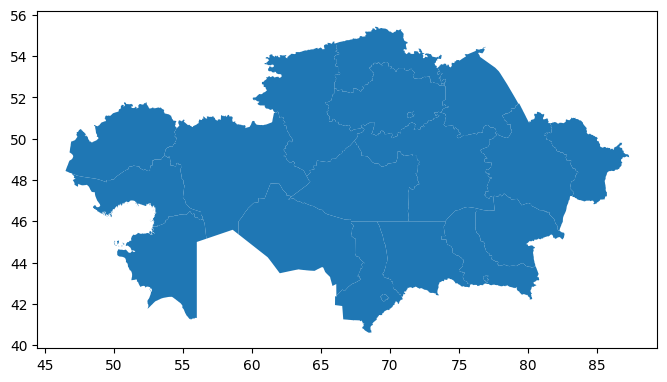

In [11]:
# Utility: Load and combine all region shapefiles in a folder into a single GeoDataFrame
# Requirements: geopandas, shapely
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon, MultiPolygon
def load_regions(folder_path: str,
                 target_crs: str = "EPSG:4326",
                 pattern: str = "*.shp",
                 add_source: bool = True,
                 fix_invalid: bool = True,
                 dissolve: bool = False) -> gpd.GeoDataFrame:
    folder = Path(folder_path)
    if not folder.exists() or not folder.is_dir():
        raise FileNotFoundError(f"Folder not found or not a directory: {folder}")
    shp_files = sorted(folder.glob(pattern))
    if not shp_files:
        raise FileNotFoundError(f"No shapefiles found in {folder} matching pattern {pattern}")
    gdfs: list[gpd.GeoDataFrame] = []
    for shp in shp_files:
        try:
            gdf = gpd.read_file(shp)
        except Exception as e:
            print(f"[WARN] Failed to read {shp.name}: {e}")
            continue
        if gdf.empty:
            print(f"[INFO] Empty shapefile skipped: {shp.name}")
            continue
        # Ensure CRS
        if gdf.crs is None:
            gdf.set_crs(target_crs, inplace=True)
        elif gdf.crs.to_string() != target_crs:
            gdf = gdf.to_crs(target_crs)
        # Optional add source file name
        if add_source:
            gdf["source_file"] = shp.stem
        # Fix invalid geometries (common for topology errors)
        if fix_invalid and not gdf.geometry.is_valid.all():
            gdf["geometry"] = gdf.geometry.buffer(0)
        # Keep only polygonal geometries
        gdf = gdf[gdf.geometry.notna()]
        gdf = gdf[gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
        gdfs.append(gdf)
    if not gdfs:
        raise ValueError("All shapefiles failed to load or were empty.")
    # Align columns (outer join) and concatenate
    combined = pd.concat(gdfs, ignore_index=True, sort=False)
    # Optionally dissolve
    if dissolve:
        if dissolve_field and dissolve_field in combined.columns:
            combined = combined.dissolve(by=dissolve_field, as_index=False)
        else:
            combined = combined.dissolve()
            combined = combined.reset_index(drop=True)

    # Final sanity check
    combined.crs = target_crs
    combined = combined[combined.geometry.notna()]
    combined = combined[~combined.geometry.is_empty]
    print(f"Loaded {len(shp_files)} shapefiles; combined rows: {len(combined)}; CRS: {combined.crs}")
    return combined
# Example usage (uncomment to run):
regions = load_regions('kz_regions_shp')
print(regions.head())
regions.plot(figsize=(8,6))

In [16]:
# Step 1: Spatial join to attach stats_gdf attributes to existing region polygons
#regions_with_stats = regions.sjoin(stats_gdf, how='left', predicate='contains')
# Clean up duplicate columns from the join
#if 'index_right' in regions_with_stats.columns:
#    regions_with_stats = regions_with_stats.drop(columns=['index_right'])
#Step 2: Create buffer polygons around centroids for subregions
#stats_gdf_polygons = stats_gdf.copy()
#buffer_size = 0.05  # Adjust as needed (degrees)
#stats_gdf_polygons['geometry'] = stats_gdf_polygons.geometry.buffer(buffer_size)
# Step 3: Combine both - region polygons (with stats) + subregion buffer polygons
#combined_gdf = pd.concat([regions_with_stats, stats_gdf_polygons], 
#                         ignore_index=True, 
#                         sort=False)
# Ensure consistent CRS
#combined_gdf.crs = regions.crs
# Summary
#print(f"Original regions: {len(regions)}")
#print(f"Regions with stats (after join): {len(regions_with_stats)}")
#print(f"Subregion buffer polygons: {len(stats_gdf_polygons)}")
#print(f"Combined total polygons: {len(combined_gdf)}")
#print(f"\nAll columns: {combined_gdf.columns.tolist()}")
#print(f"\nFirst few rows:\n{combined_gdf.head()}")

In [12]:
del regions['source']
del regions['source_file']

In [18]:
# Step 1: Spatial join to attach stats_gdf attributes to region polygons
#regions_with_stats = regions.sjoin(stats_gdf, how='left', predicate='contains')
# Clean up duplicate columns from the join
#if 'index_right' in regions_with_stats.columns:
#    regions_with_stats = regions_with_stats.drop(columns=['index_right'])
# Step 2: Create buffer polygons around centroids for subregions
#stats_gdf_polygons = stats_gdf.copy()
#buffer_size = 0.05  # Adjust as needed (degrees, ≈5-6 km at Kazakhstan latitude)
#stats_gdf_polygons['geometry'] = stats_gdf_polygons.geometry.buffer(buffer_size)
# Step 3: Combine both - region polygons (with stats) + subregion buffer polygons
#combined_gdf = pd.concat([regions_with_stats, stats_gdf_polygons], 
#                         ignore_index=True, 
#                         sort=False)
# Ensure consistent CRS
#combined_gdf.crs = regions.crs
#Summary
#print(f"Original regions: {len(regions)}")
#print(f"Regions with stats (after join): {len(regions_with_stats)}")
#print(f"Subregion buffer polygons: {len(stats_gdf_polygons)}")
#print(f"Combined total polygons: {len(combined_gdf)}")
#print(f"\nAll columns preserved: {combined_gdf.columns.tolist()}")
#print(f"\nSample data:\n{combined_gdf.head()}")

In [19]:
# Diagnostic: Check what's actually in each variable
#print("=== DIAGNOSTIC ===")
#print(f"regions.shape: {regions.shape}")
#print(f"stats_gdf.shape: {stats_gdf.shape}")
#print(f"regions_with_stats.shape: {regions_with_stats.shape}")
#print(f"stats_gdf_polygons.shape: {stats_gdf_polygons.shape}")
#print(f"combined_gdf.shape: {combined_gdf.shape}")
#print(f"\nExpected combined_gdf rows: {len(regions_with_stats)} + {len(stats_gdf_polygons)} = {len(regions_with_stats) + len(stats_gdf_polygons)}")
#print(f"Actual combined_gdf rows: {len(combined_gdf)}")

# Check geometry types
#print(f"\nGeometry types in stats_gdf:")
#print(stats_gdf.geometry.geom_type.value_counts())

#print(f"\nGeometry types in stats_gdf_polygons:")
#print(stats_gdf_polygons.geometry.geom_type.value_counts())

#print(f"\nGeometry types in combined_gdf:")
#print(combined_gdf.geometry.geom_type.value_counts())


In [20]:
# Visualize combined_gdf - showing UNIQUE regions + buffer polygons
#import matplotlib.pyplot as plt
#fig, ax = plt.subplots(figsize=(16, 12))
# Plot ORIGINAL 20 regions (not the 228 duplicated rows)
#regions.plot(ax=ax, color='lightblue', edgecolor='black', 
#             alpha=0.4, linewidth=2, label=f'Original Regions ({len(regions)})')
# Plot the 228 buffer polygons (second half of combined_gdf)
#n_regions_with_stats = len(regions_with_stats)
#buffers_part = combined_gdf.iloc[n_regions_with_stats:]  # Last 228 rows = buffers
#buffers_part.plot(ax=ax, color='red', edgecolor='darkred', 
#                  alpha=0.4, linewidth=0.5, label=f'Subregion buffers ({len(buffers_part)})')
# Plot original centroids as yellow points
#stats_gdf.plot(ax=ax, color='yellow', markersize=25, 
#               marker='o', edgecolor='black', linewidth=0.8, label=f'Centroids ({len(stats_gdf)})', zorder=5)
#ax.legend(fontsize=14, loc='upper right')
#ax.set_title('Combined GeoDataFrame Visualization', fontsize=18, fontweight='bold')
#ax.set_xlabel('Longitude', fontsize=14)
#ax.set_ylabel('Latitude', fontsize=14)
#ax.grid(True, alpha=0.3, linestyle='--')
#plt.tight_layout()
#plt.show()
#print(f"\n✓ Visualization shows:")
#print(f"  - {len(regions)} unique region polygons (lightblue)")
#print(f"  - {len(buffers_part)} subregion buffer circles (red)")
#print(f"  - {len(stats_gdf)} centroids (yellow dots)")
#print(f"\n✓ combined_gdf contains {len(combined_gdf)} total rows:")
#print(f"  - {n_regions_with_stats} region-centroid join results")
#print(f"  - {len(buffers_part)} buffer polygons")

In [13]:
hp_gdf = gpd.GeoDataFrame(data1.copy(), geometry=gpd.points_from_xy(data1.LONGITUDE, data1.LATITUDE), crs='EPSG:4326')
print('Data loaded: regions', len(regions), 'centroids', len(stats_gdf), 'house points', len(hp_gdf))

# Interpolate & Join socio-economic attributes to regions
# Spatial join centroids to polygons (one-to-many if needed)
centroid_join = gpd.sjoin(stats_gdf, regions, how='left', predicate='within')
if 'index_right' in centroid_join.columns:
    centroid_join.rename(columns={'index_right':'region_poly_idx'}, inplace=True)

# Aggregate centroids per polygon by mean (or choose median)
# Filter to only NUMERIC columns to avoid TypeError with mean()
attr_cols = [c for c in required_cols if c not in ['latitude','longitude','region']]
numeric_attr_cols = [c for c in attr_cols if c in centroid_join.select_dtypes(include=[np.number]).columns]

print(f"Aggregating {len(numeric_attr_cols)} numeric attributes")

poly_attr = centroid_join.groupby('region_poly_idx')[numeric_attr_cols].mean().reset_index()
regions_enriched = regions.reset_index().merge(poly_attr, left_on='index', right_on='region_poly_idx', how='left')

# Identify polygons missing any attribute after centroid merge
missing_mask = regions_enriched[numeric_attr_cols].isna().any(axis=1)
print('Polygons with missing attributes needing interpolation:', missing_mask.sum())

Data loaded: regions 20 centroids 228 house points 588300
Aggregating 27 numeric attributes
Polygons with missing attributes needing interpolation: 1


In [14]:
# IDW interpolation from nearest k centroids for missing polygons
from scipy.spatial import cKDTree

if missing_mask.sum() > 0:
    # Prepare arrays
    centroid_xy = np.vstack([stats_gdf.geometry.x.values, stats_gdf.geometry.y.values]).T
    tree = cKDTree(centroid_xy)
    k = min(8, len(stats_gdf))
    target_centroids = regions_enriched.loc[missing_mask, 'geometry'].centroid
    target_xy = np.vstack([target_centroids.x.values, target_centroids.y.values]).T
    dists, idxs = tree.query(target_xy, k=k)
    # Ensure shape (n_missing, k)
    if k == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]
    # IDW weight = 1 / d^p
    p = 2
    dists = np.where(dists == 0, 1e-12, dists)
    weights = 1 / (dists ** p)
    weights = weights / weights.sum(axis=1, keepdims=True)
    for col in attr_cols:
        vals = stats_gdf[col].values
        interpolated = (weights * vals[idxs]).sum(axis=1)
        regions_enriched.loc[missing_mask, col] = interpolated

# Final check
print('Remaining NA counts after interpolation:')
print(regions_enriched[attr_cols].isna().sum())

ENRICHED_SHP = os.path.join(BASE_DIR, 'regions_enriched.shp')
if os.path.exists(ENRICHED_SHP):
    for ext in ['.shp','.shx','.dbf','.prj','.cpg']:
        p = ENRICHED_SHP.replace('.shp', ext)
        if os.path.exists(p):
            os.remove(p)
regions_enriched.to_file(ENRICHED_SHP)
print('Saved enriched regions shapefile:', ENRICHED_SHP)

Remaining NA counts after interpolation:
index_potreb_cen_tovary_uslugi                                        0
index_potreb_cen_prodovolstv_tovary                                   0
index_potreb_cen_neprodovolstv_tovary                                 0
index_potreb_cen_platnye_uslugi                                       0
srednmes_zarplata                                                     0
index_real_zarplaty                                                   0
chislennost_naseleniya_092025                                         0
prirost_naselenya                                                     0
temp_prirosta_percent                                                 0
obsh_ploshad_expluat_new_buildings_vsego                              0
obsh_ploshad_expluat_new_buildings_zhilye                             0
obsh_ploshad_expluat_new_buildings_shkoly                             1
fakt_stoimost_str_va_vsego                                            0
fakt_stoimost_str_va_zh

C:\Users\00055794\AppData\Local\Temp\ipykernel_1104\294264531.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_centroids = regions_enriched.loc[missing_mask, 'geometry'].centroid
C:\Users\00055794\AppData\Local\Temp\ipykernel_1104\294264531.py:36: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  regions_enriched.to_file(ENRICHED_SHP)
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'region_poly_idx' to 'region_pol'
  ogr_write(
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_potreb_cen_tovary_uslugi' to 'index_potr'
  ogr_write(
c:\Users\00055794\Desktop\Gulnaz\PROJECTS\BZK_2025\venv\Lib\site-

In [15]:
# === Join hp_gdf with stats_gdf features using IDW interpolation ===
# Goal: Add socio-economic features from stats_gdf to each house price point in hp_gdf

from scipy.spatial import cKDTree

# Get numeric columns from stats_gdf to interpolate
stats_numeric_cols = stats_gdf.select_dtypes(include=[np.number]).columns.tolist()
# Exclude latitude/longitude if they exist
stats_numeric_cols = [c for c in stats_numeric_cols if c not in ['latitude', 'longitude']]

print(f"Interpolating {len(stats_numeric_cols)} features from stats_gdf to hp_gdf")
print(f"Features: {stats_numeric_cols[:10]}...")  # Show first 10

# Build KD-Tree from stats_gdf centroids
stats_xy = np.vstack([stats_gdf.geometry.x.values, stats_gdf.geometry.y.values]).T
tree = cKDTree(stats_xy)

# Get house price point coordinates
hp_xy = np.vstack([hp_gdf.geometry.x.values, hp_gdf.geometry.y.values]).T

# Find k nearest stats centroids for each house point
k = min(8, len(stats_gdf))  # Use 8 nearest neighbors or less if fewer stats points
dists, idxs = tree.query(hp_xy, k=k)

# Handle single neighbor case
if k == 1:
    dists = dists[:, None]
    idxs = idxs[:, None]

# Calculate IDW weights
p = 2  # Power parameter
dists = np.where(dists == 0, 1e-12, dists)  # Avoid division by zero
weights = 1 / (dists ** p)
weights = weights / weights.sum(axis=1, keepdims=True)  # Normalize

# Interpolate each feature
print(f"Interpolating to {len(hp_gdf)} house points...")
for col in stats_numeric_cols:
    if col in stats_gdf.columns:
        vals = stats_gdf[col].values
        # Handle NaN values - use only valid neighbors
        interpolated = np.zeros(len(hp_gdf))
        for i in range(len(hp_gdf)):
            neighbor_vals = vals[idxs[i]]
            neighbor_weights = weights[i]
            # Filter out NaN neighbors
            valid_mask = ~np.isnan(neighbor_vals)
            if valid_mask.any():
                valid_vals = neighbor_vals[valid_mask]
                valid_weights = neighbor_weights[valid_mask]
                valid_weights = valid_weights / valid_weights.sum()  # Re-normalize
                interpolated[i] = (valid_weights * valid_vals).sum()
            else:
                interpolated[i] = np.nan
        
        # Add to data1
        data1[col] = interpolated

print(f"✓ Added {len(stats_numeric_cols)} interpolated features to data1")
print(f"data1 shape: {data1.shape}")
print(f"\nSample of interpolated features:")
print(data1[stats_numeric_cols[:5]].head())

Interpolating 28 features from stats_gdf to hp_gdf
Features: ['No', 'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 'prirost_naselenya', 'temp_prirosta_percent']...
Interpolating to 588300 house points...
✓ Added 28 interpolated features to data1
data1 shape: (588300, 43)

Sample of interpolated features:
         No  index_potreb_cen_tovary_uslugi  \
0  8.186846                      100.800000   
1  2.435069                      101.101340   
2  9.764626                      100.800000   
3  4.662397                      101.103304   
4  9.822288                      100.800000   

   index_potreb_cen_prodovolstv_tovary  index_potreb_cen_neprodovolstv_tovary  \
0                           100.700000                             101.200000   
1                           100.608040                             101

In [16]:
data1.head(2)

,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,...,obsh_ploshad_expluat_new_buildings_zhilye_individualnye,obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye,poleznaya_ploshad_zhilyh_zdaniy_vvedeno,poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishikami,k_vo_vvedennyh_kvartir_vsego,k_vo_vvedennyh_kvartir_indiv_zastroishikami,k_vo_vvedennyh_novyh_zhilyh_zdaniy_vsego,k_vo_vvedennyh_novyh_zhilyh_zdaniy_indiv,k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh,sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego
0,3,76.893760,43.237206,90.4,6,18,Оркендеу,3,4,3.0,...,11337.087941,205243.719829,165293.433547,163499.770922,2696.131292,58.358771,73.857112,39.955933,33.901179,264.230141
1,1,71.555289,51.131212,36.0,6,9,нет данных,1,4,2.7,...,9112.065680,306363.284455,241803.302953,224131.535297,3542.835171,18.102844,33.032119,19.050655,13.715919,300.530946


In [17]:
# Compute house price point density per enriched region
if len(hp_gdf) > 0:
    hp_join = gpd.sjoin(hp_gdf, regions_enriched[['index','geometry']], how='left', predicate='within')
    counts = hp_join.groupby('index').size().rename('house_point_count')
    
    # Drop existing columns if they exist to avoid conflict
    cols_to_drop = ['house_point_count', 'area_km2', 'density_hp_per_km2']
    regions_enriched = regions_enriched.drop(columns=[c for c in cols_to_drop if c in regions_enriched.columns])
    
    # Now join
    regions_enriched = regions_enriched.join(counts, on='index')
else:
    regions_enriched['house_point_count'] = 0

# Project to equal-area (Web Mercator approximated for density) for area calc
regions_proj = regions_enriched.to_crs('EPSG:3857')
regions_enriched['area_km2'] = regions_proj.geometry.area / 1e6
regions_enriched['density_hp_per_km2'] = regions_enriched['house_point_count'] / regions_enriched['area_km2'].replace({0:np.nan})
regions_enriched['density_hp_per_km2'] = regions_enriched['density_hp_per_km2'].fillna(0)
print(regions_enriched[['house_point_count','area_km2','density_hp_per_km2']].head())

   house_point_count       area_km2  density_hp_per_km2
0              20427  381477.352563            0.053547
1              39299  687637.411337            0.057151
2              12762  205128.288210            0.062215
3             138613    1326.117051          104.525464
4              15326  257825.280199            0.059443


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
sc = StandardScaler()

In [19]:
# Build weighted feature matrix
importance_order = [
    'srednmes_zarplata',
    'index_real_zarplaty',
    'sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego', 
    'chislennost_naseleniya_092025',
    'prirost_naselenya',
    'temp_prirosta_percent',
    'obsh_ploshad_expluat_new_buildings_zhilye', 
    'fakt_stoimost_str_va_zhilye', 
    'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 
    'poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishikami', 
    'k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh', 
    'k_vo_vvedennyh_kvartir_indiv_zastroishikami',
    'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 
    'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_zasrtoishikami_sqmeters', 
    'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 
    'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 
    'index_potreb_cen_tovary_uslugi',
    'index_potreb_cen_prodovolstv_tovary',
    'index_potreb_cen_neprodovolstv_tovary',
    'index_potreb_cen_platnye_uslugi'
]
# Derived features (optional) could be appended here
features = importance_order.copy()
# Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(regions_enriched[features])
# Weights: higher weight for earlier features (geometric decay)
alpha = 0.85
weights = np.array([alpha**i for i in range(len(features))])
weights = weights / weights.sum()

X_weighted = X_std * weights
regions_enriched['composite_score'] = X_weighted.sum(axis=1)
print('Weights mapping:')
for f,w in zip(features, weights):
    print(f'{f}: {w:.3f}')
print(regions_enriched[['composite_score']+features].head())

Weights mapping:
srednmes_zarplata: 0.156
index_real_zarplaty: 0.133
sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego: 0.113
chislennost_naseleniya_092025: 0.096
prirost_naselenya: 0.081
temp_prirosta_percent: 0.069
obsh_ploshad_expluat_new_buildings_zhilye: 0.059
fakt_stoimost_str_va_zhilye: 0.050
fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami: 0.043
poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishikami: 0.036
k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh: 0.031
k_vo_vvedennyh_kvartir_indiv_zastroishikami: 0.026
obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters: 0.022
obsh_ploshad_vveden_expluat_zhilyh_zdaniy_zasrtoishikami_sqmeters: 0.019
obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye: 0.016
obsh_ploshad_expluat_new_buildings_zhilye_individualnye: 0.014
index_potreb_cen_tovary_uslugi: 0.012
index_potreb_cen_prodovolstv_tovary: 0.010
index_potreb_cen_neprodovolstv_tovary: 0.008
index_potreb_cen_platnye_uslugi: 0.007
   composite_score  srednmes_zarplata

In [20]:
print(hp_gdf.columns.tolist())

['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'REGION', 'CITY_CAT', 'PRICE_ln', 'geometry']


In [23]:
# Segmentation Configuration & Imports
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings('ignore')

# Optional libraries (handled with fallbacks)
try:
    from libpysal.weights import Queen
    from spopt.region import WardSpatial, Skater
except Exception as e:
    Queen = None
    WardSpatial = None
    Skater = None
    print("Warning: spopt/libpysal not fully available:", e)

try:
    import hdbscan
except Exception:
    hdbscan = None

# File / path settings (adjust if needed)
DATA_DIR = Path('.')
REGION_FILE = DATA_DIR / 'regions_enriched.shp'  # if already exported; else build from in-memory gdf
HP_FILE = DATA_DIR / 'hp_points_with_geom.geojson'  # optional saved points with geometry

# Output paths
OUT_REGION_CLUSTER_FILE = DATA_DIR / 'regions_macro_segments.shp'
OUT_POINTS_FILE = DATA_DIR / 'hp_points_with_segments.parquet'
OUT_CLUSTER_SUMMARY = DATA_DIR / 'segment_summary.csv'
OUT_META_JSON = DATA_DIR / 'segment_meta.json'

# Clustering parameters
CANDIDATE_K = list(range(6, 13))  # region-level K search space
EARLY_STOP_PATIENCE = 2
USE_PCA = True
PCA_VARIANCE = 0.95
SIMPLIFY_TOL = 0.0005  # degrees (approx ~55m at equator * cos(lat))
REFINE_METHOD = 'hdbscan'  # 'hdbscan' or 'kmeans' or None
MIN_POINTS_REFINE = 800
HDBSCAN_MIN_CLUSTER_SIZE = 150
HDBSCAN_MIN_SAMPLES = 30
KMEANS_MICRO_PER_1000 = 1  # approximate micro clusters per 1000 points (if kmeans refinement)
RANDOM_STATE = 42

# Feature columns to use from regions_enriched if present
REGION_FEATURES_BASE = [
    'population',
    'srednmes_zarplata',
    'index_real_zarplaty',
    'sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego', 
    'chislennost_naseleniya_092025',
    'prirost_naselenya',
    'temp_prirosta_percent',
    'obsh_ploshad_expluat_new_buildings_zhilye', 
    'fakt_stoimost_str_va_zhilye', 
    'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 
    'poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishikami', 
    'k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh', 
    'k_vo_vvedennyh_kvartir_indiv_zastroishikami',
    'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 
    'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_zasrtoishikami_sqmeters', 
    'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 
    'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 
    'index_potreb_cen_tovary_uslugi',
    'index_potreb_cen_prodovolstv_tovary',
    'index_potreb_cen_neprodovolstv_tovary',
    'index_potreb_cen_platnye_uslugi'
    'house_point_count',
    'area_km2',
    'density_hp_per_km2',
    'composite_score'
]

# Attempt to access in-memory objects if they exist (they might already be loaded earlier in notebook)
if 'regions_enriched' in globals():
    regions_gdf = regions_enriched.copy()
else:
    if REGION_FILE.exists():
        regions_gdf = gpd.read_file(REGION_FILE)
    else:
        raise FileNotFoundError('regions_enriched GeoDataFrame not found in memory and regions_enriched.shp not present.')

if 'hp_gdf' in globals():
    hp_points_gdf = hp_gdf.copy()
else:
    if HP_FILE.exists():
        hp_points_gdf = gpd.read_file(HP_FILE)
    else:
        raise FileNotFoundError('hp_gdf not found in memory and hp_points_with_geom.geojson not present.')

# Ensure CRS consistency
if regions_gdf.crs is None:
    regions_gdf.set_crs(epsg=4326, inplace=True)
if hp_points_gdf.crs is None:
    hp_points_gdf.set_crs(epsg=4326, inplace=True)
if regions_gdf.crs != hp_points_gdf.crs:
    hp_points_gdf = hp_points_gdf.to_crs(regions_gdf.crs)

# Simplify geometry for faster adjacency if large
if SIMPLIFY_TOL and SIMPLIFY_TOL > 0:
    regions_gdf['geometry_simpl'] = regions_gdf.geometry.simplify(SIMPLIFY_TOL, preserve_topology=True)
else:
    regions_gdf['geometry_simpl'] = regions_gdf.geometry

print(f"Regions: {len(regions_gdf)} | Points: {len(hp_points_gdf)}")

Regions: 20 | Points: 588300


In [24]:
# Segmentation Helper Functions
from typing import List, Tuple, Dict, Optional


def build_region_feature_matrix(regions: gpd.GeoDataFrame,
                                feature_cols: List[str],
                                use_pca: bool = True,
                                pca_var: float = 0.95) -> Tuple[pd.DataFrame, np.ndarray, Optional[PCA], StandardScaler]:
    df = regions.copy()
    available = [c for c in feature_cols if c in df.columns]
    X = df[available].replace([np.inf, -np.inf], np.nan)
    # Impute with column medians
    X = X.apply(lambda s: s.fillna(s.median()))
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)
    pca_model = None
    if use_pca and X_scaled.shape[1] > 2:
        pca_model = PCA(n_components=pca_var, svd_solver='full', random_state=RANDOM_STATE)
        X_final = pca_model.fit_transform(X_scaled)
    else:
        X_final = X_scaled
    feature_df = pd.DataFrame(X_final, index=df.index)
    return feature_df, X_final, pca_model, scaler


def _queen_weights(regions: gpd.GeoDataFrame):
    if Queen is None:
        raise ImportError('libpysal is required for spatial weights.')
    return Queen.from_dataframe(regions, geom_col='geometry_simpl')


def ward_best_k_regions(X: np.ndarray, regions: gpd.GeoDataFrame, candidate_k: List[int], patience: int = 2) -> Tuple[np.ndarray, int, Dict]:
    if WardSpatial is None:
        raise ImportError('spopt WardSpatial required.')
    w = _queen_weights(regions)
    best_score = -1
    best_labels = None
    best_k = None
    history = []
    no_improve = 0
    for k in candidate_k:
        try:
            ward = WardSpatial(regions, w, k, attrs_name=list(range(X.shape[1])))
            ward.solve()
            labels = np.array(ward.labels_)
            # Silhouette (needs >1 cluster and < n_samples clusters)
            if len(set(labels)) > 1 and len(set(labels)) < len(labels):
                try:
                    sc = silhouette_score(X, labels)
                except Exception:
                    sc = np.nan
            else:
                sc = np.nan
            history.append({'k': k, 'silhouette': sc})
            if sc > best_score:
                best_score = sc
                best_labels = labels
                best_k = k
                no_improve = 0
            else:
                no_improve += 1
            if patience and no_improve >= patience and best_k is not None:
                break
        except Exception as e:
            history.append({'k': k, 'silhouette': np.nan, 'error': str(e)})
            continue
    meta = {'history': history, 'best_score': best_score}
    if best_labels is None:
        raise RuntimeError('WardSpatial failed for all candidate k.')
    return best_labels, best_k, meta


def skater_best_k_regions(X: np.ndarray, regions: gpd.GeoDataFrame, candidate_k: List[int]) -> Tuple[np.ndarray, int, Dict]:
    if Skater is None:
        raise ImportError('spopt Skater required.')
    w = _queen_weights(regions)
    best_score = -1
    best_labels = None
    best_k = None
    history = []
    for k in candidate_k:
        try:
            sk = Skater(regions, w, list(range(X.shape[1])), n_clusters=k)
            sk.solve()
            labels = np.array(sk.labels_)
            if len(set(labels)) > 1 and len(set(labels)) < len(labels):
                try:
                    sc = silhouette_score(X, labels)
                except Exception:
                    sc = np.nan
            else:
                sc = np.nan
            history.append({'k': k, 'silhouette': sc})
            if sc > best_score:
                best_score = sc
                best_labels = labels
                best_k = k
        except Exception as e:
            history.append({'k': k, 'silhouette': np.nan, 'error': str(e)})
            continue
    meta = {'history': history, 'best_score': best_score}
    if best_labels is None:
        raise RuntimeError('Skater failed for all candidate k.')
    return best_labels, best_k, meta


def assign_region_clusters(regions: gpd.GeoDataFrame, labels: np.ndarray, label_col: str = 'macro_seg') -> gpd.GeoDataFrame:
    regions = regions.copy()
    regions[label_col] = labels
    return regions


def refine_point_clusters_hdbscan(points: gpd.GeoDataFrame, macro_col: str = 'macro_seg', min_cluster_size: int = 150, min_samples: int = 30) -> gpd.GeoDataFrame:
    if hdbscan is None:
        print('HDBSCAN not installed; skipping refinement.')
        points['micro_seg'] = -1
        return points
    pts = points.copy()
    micro_labels = np.full(len(pts), -1, dtype=int)
    for macro in sorted(pts[macro_col].unique()):
        sub_idx = pts[pts[macro_col] == macro].index
        if len(sub_idx) < MIN_POINTS_REFINE:
            continue
        sub = pts.loc[sub_idx]
        coords = np.vstack([sub.geometry.x.values, sub.geometry.y.values]).T
        try:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, cluster_selection_epsilon=0.0)
            cl = clusterer.fit_predict(coords)
            if len(set(cl)) > 1:
                # offset labels to ensure uniqueness across macros
                # map -1 noise stays -1
                unique_pos = [u for u in np.unique(cl) if u >= 0]
                if unique_pos:
                    offset = (max(micro_labels) + 1) if micro_labels.max() >= 0 else 0
                    cl_offset = np.array([c + offset if c >= 0 else -1 for c in cl])
                else:
                    cl_offset = cl
                micro_labels[sub_idx] = cl_offset
        except Exception as e:
            print(f'HDBSCAN failed for macro {macro}: {e}')
            continue
    pts['micro_seg'] = micro_labels
    return pts


def refine_point_clusters_kmeans(points: gpd.GeoDataFrame, macro_col: str = 'macro_seg', per_1000: int = 1) -> gpd.GeoDataFrame:
    pts = points.copy()
    micro_labels = np.full(len(pts), -1, dtype=int)
    current_offset = 0
    for macro in sorted(pts[macro_col].unique()):
        sub_idx = pts[pts[macro_col] == macro].index
        n = len(sub_idx)
        if n < MIN_POINTS_REFINE:
            continue
        k = max(2, int(np.ceil(n / 1000 * per_1000)))
        sub = pts.loc[sub_idx]
        coords = np.vstack([sub.geometry.x.values, sub.geometry.y.values]).T
        try:
            km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=4096)
            cl = km.fit_predict(coords)
            cl_offset = cl + current_offset
            micro_labels[sub_idx] = cl_offset
            current_offset += k
        except Exception as e:
            print(f'KMeans refinement failed for macro {macro}: {e}')
    pts['micro_seg'] = micro_labels
    return pts


def compose_segment_id(points: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    pts = points.copy()
    if 'micro_seg' in pts.columns and (pts['micro_seg'] >= 0).any():
        pts['segment_id'] = pts.apply(lambda r: f"M{int(r['macro_seg'])}-m{int(r['micro_seg'])}" if r['micro_seg'] >= 0 else f"M{int(r['macro_seg'])}", axis=1)
    else:
        pts['segment_id'] = pts['macro_seg'].apply(lambda v: f"M{int(v)}")
    return pts


def summarize_clusters(points: gpd.GeoDataFrame, regions: gpd.GeoDataFrame) -> pd.DataFrame:
    cols_numeric = ['population','srednmes_zarplata','density_hp_per_km2','composite_score','PRICE_ln']
    summary_list = []
    for seg, group in points.groupby('segment_id'):
        region_sub = regions[regions['macro_seg'] == group.iloc[0]['macro_seg']]
        record = {
            'segment_id': seg,
            'macro_seg': group.iloc[0]['macro_seg'],
            'points': len(group),
            'regions': region_sub.shape[0]
        }
        for c in cols_numeric:
            if c in group.columns:
                record[f'pt_mean_{c}'] = group[c].mean()
        if 'area_km2' in region_sub.columns:
            record['region_area_km2'] = region_sub['area_km2'].sum()
        summary_list.append(record)
    return pd.DataFrame(summary_list)

print('Helper functions loaded.')

Helper functions loaded.


In [25]:
print(data1.columns.tolist())

['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'REGION', 'CITY_CAT', 'PRICE_ln', 'No', 'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 'prirost_naselenya', 'temp_prirosta_percent', 'obsh_ploshad_expluat_new_buildings_vsego', 'obsh_ploshad_expluat_new_buildings_zhilye', 'obsh_ploshad_expluat_new_buildings_shkoly', 'fakt_stoimost_str_va_vsego', 'fakt_stoimost_str_va_zhilye', 'fakt_stoimost_str_va_shkoly', 'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno', 'poleznaya_ploshad_zhilyh_zdaniy_

In [26]:
# === Fine-Grained Housing Segmentation: Heuristic (No Fixed Target) ===
# Updated: removes fixed segment count, adds richer heuristics + optional second-pass splitting.
# New: enforce_non_overlap option to produce non-intersecting segment polygons (greedy difference).

import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from shapely.ops import unary_union
from typing import Iterable, Optional, Tuple


def fine_segment_housing(
    hp_gdf: gpd.GeoDataFrame,
    regions_gdf: gpd.GeoDataFrame,
    region_key_candidates: Iterable[str] = ("id", "poly_index", "code"),
    region_attr_cols: Iterable[str] = (
    'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 
    'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 
    'prirost_naselenya', 'temp_prirosta_percent', 'obsh_ploshad_expluat_new_buildings_vsego', 'obsh_ploshad_expluat_new_buildings_zhilye', 
    'obsh_ploshad_expluat_new_buildings_shkoly', 'fakt_stoimost_str_va_vsego', 'fakt_stoimost_str_va_zhilye', 'fakt_stoimost_str_va_shkoly', 
    'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 
    'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 
    'poleznaya_ploshad_zhilyh_zdaniy_vvedeno', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishikami', 'k_vo_vvedennyh_kvartir_vsego', 
    'k_vo_vvedennyh_kvartir_indiv_zastroishikami', 'k_vo_vvedennyh_novyh_zhilyh_zdaniy_vsego', 'k_vo_vvedennyh_novyh_zhilyh_zdaniy_indiv', 
    'k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh', 
    'sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego',
         "house_point_count",
         "area_km2",
        "density_hp_per_km2",
    ),
    # --- Heuristic granularity controls ---
    target_total_segments: Optional[int] = None,  # keep None to rely on heuristics
    k_factor: float = 1.15,            # increase above 0.65 for more segments
    desired_avg_points: Optional[int] = 340,  # alternative heuristic (N / desired_avg_points)
    alpha_exp: float = 0.8,            # >0.5 => more weight to large regions => more splits
    min_points_to_split: int = 50,      # allow more regions to split
    max_segments_region: int = 1200,   # per-region cap
    min_segments_region: int = 1,
    # --- Feature weighting ---
    geo_weight: float = 1.0,
    jitter_scale: float = 0.0,
    # --- Polygonization ---
    use_metric_crs: bool = True,
    metric_crs: str = "EPSG:3857",
    buffer_radius_m: float = 1800.0,
    hull_min_points: int = 5,
    # --- Second pass refinement ---
    enable_second_pass: bool = True,
    second_pass_max_points: int = 850,         # if a segment has more than this, consider splitting
    second_pass_target_avg: int = 420,         # aim for this average size on big segments
    second_pass_max_new_segments: int = 1200,  # safety cap on added segments
    # --- Non-overlap enforcement ---
    enforce_non_overlap: bool = True,          # make polygons non-intersecting
    non_overlap_order: str = 'points',         # 'points' (by segment size) or 'none'
    min_area_m2: float = 0.0,                  # drop slivers below this area (in metric CRS) if > 0
    # --- KMeans / runtime ---
    random_state: int = 42,
    batch_size: int = 4096,
    # --- Persistence ---
    persist: bool = True,
    persist_prefix: str = "segments_fine_heuristic",
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, pd.DataFrame]:
    if hp_gdf.empty:
        raise ValueError("hp_gdf is empty")
    if regions_gdf.empty:
        raise ValueError("regions_gdf is empty")

    points = hp_gdf.copy()
    regions = regions_gdf.copy()

    # Detect region key
    region_key = None
    for cand in region_key_candidates:
        if cand in regions.columns:
            region_key = cand
            break
    if region_key is None:
        regions = regions.reset_index().rename(columns={"index": "region_key"})
        region_key = "region_key"

    if regions.crs is None:
        raise ValueError("regions_gdf CRS is None; set it before calling.")
    if points.crs is None:
        points = points.set_crs(regions.crs)
    if points.crs != regions.crs:
        points = points.to_crs(regions.crs)

    base_crs = regions.crs

    # Region attributes subset
    region_attr_cols = [c for c in region_attr_cols if c in regions.columns]
    keep_cols = [region_key, 'geometry'] + region_attr_cols
    regions_subset = regions[keep_cols]

    # Spatial join
    joined = gpd.sjoin(points, regions_subset, how='left', predicate='within')
    miss = joined[region_key].isna().sum()
    if miss:
        print(f"[INFO] {miss} points outside region polygons; dropping.")
        joined = joined.dropna(subset=[region_key])
    N = len(joined)
    if N == 0:
        raise ValueError("No points after join.")

    # Heuristic target
    if target_total_segments is None:
        h1 = k_factor * np.sqrt(N)
        h2 = N / desired_avg_points if desired_avg_points else 0
        target_total_segments = int(max(h1, h2))
    target_total_segments = max(target_total_segments, 21)
    target_total_segments = min(target_total_segments, 4572)
    print(f"Heuristic target_total_segments={target_total_segments}")

    # Allocation
    region_counts = joined[region_key].value_counts().rename('n')
    weights = region_counts.pow(alpha_exp)
    alloc_float = weights / weights.sum() * target_total_segments
    alloc = pd.DataFrame({region_key: alloc_float.index, 'alloc_float': alloc_float.values, 'n': region_counts.values})
    alloc['k_region'] = alloc['alloc_float'].apply(lambda v: max(min_segments_region, int(np.floor(v))))
    alloc.loc[alloc['n'] < min_points_to_split, 'k_region'] = 1
    alloc['k_region'] = alloc['k_region'].clip(upper=max_segments_region)

    def adjust(df, target):
        diff = df['k_region'].sum() - target
        if diff == 0:
            return df
        while diff > 0:
            idxs = df[df['k_region'] > 1].sort_values('k_region', ascending=False).index
            if not len(idxs):
                break
            df.at[idxs[0], 'k_region'] -= 1
            diff -= 1
        while diff < 0:
            idxs = df.sort_values('n', ascending=False).index
            for i in idxs:
                df.at[i, 'k_region'] += 1
                diff += 1
                if diff == 0:
                    break
        return df
    alloc = adjust(alloc, target_total_segments)
    print(f"Initial allocated segments sum: {int(alloc['k_region'].sum())}")

    # Feature matrix
    attr_cols_avail = region_attr_cols
    attr_block = joined[attr_cols_avail].copy().apply(lambda s: s.fillna(s.median()))
    attr_scaler = StandardScaler() if attr_block.shape[1] else None
    attr_scaled = attr_scaler.fit_transform(attr_block) if attr_scaler else np.empty((len(joined), 0))

    geo_xy = np.vstack([joined.geometry.x.values, joined.geometry.y.values]).T
    if jitter_scale > 0:
        geo_xy = geo_xy + np.random.normal(scale=jitter_scale, size=geo_xy.shape)
    geo_scaler = StandardScaler()
    geo_scaled = geo_scaler.fit_transform(geo_xy) * geo_weight

    X = np.hstack([geo_scaled, attr_scaled])
    feat_cols = [f'f_{i}' for i in range(X.shape[1])]
    for i, c in enumerate(feat_cols):
        joined[c] = X[:, i]

    # Region-wise clustering
    joined['segment_local'] = -1
    cluster_offset = 0
    for _, row in alloc.iterrows():
        rid = row[region_key]
        k_r = int(row['k_region'])
        idx = joined[joined[region_key] == rid].index
        if not len(idx):
            continue
        if k_r <= 1:
            joined.loc[idx, 'segment_local'] = cluster_offset
            cluster_offset += 1
            continue
        subX = joined.loc[idx, feat_cols].values
        try:
            km = MiniBatchKMeans(n_clusters=k_r, random_state=random_state, batch_size=batch_size)
            labels = km.fit_predict(subX)
            joined.loc[idx, 'segment_local'] = labels + cluster_offset
            cluster_offset += k_r
        except Exception as e:
            print(f"[WARN] Region {rid} KMeans failed: {e}; fallback single cluster")
            joined.loc[idx, 'segment_local'] = cluster_offset
            cluster_offset += 1

    joined['segment_id'] = joined.apply(lambda r: f"R{r[region_key]}-S{int(r['segment_local'])}", axis=1)
    print('Segments after pass 1:', joined['segment_id'].nunique())

    # Second pass refinement: split large segments
    if enable_second_pass:
        oversized = joined.groupby('segment_id').size().loc[lambda s: s > second_pass_max_points]
        add_segments = 0
        for seg_id, size in oversized.items():
            if add_segments >= second_pass_max_new_segments:
                break
            target_subk = int(np.ceil(size / second_pass_target_avg))
            if target_subk <= 1:
                continue
            idx = joined[joined['segment_id'] == seg_id].index
            subX = joined.loc[idx, feat_cols].values
            try:
                km2 = MiniBatchKMeans(n_clusters=target_subk, random_state=random_state, batch_size=batch_size)
                sub_labels = km2.fit_predict(subX)
                # Shift existing maximum label
                max_local = joined['segment_local'].max() + 1
                joined.loc[idx, 'segment_local'] = sub_labels + max_local
                # Rebuild segment_id for these rows
                joined.loc[idx, 'segment_id'] = joined.loc[idx].apply(lambda r: f"R{r[region_key]}-S{int(r['segment_local'])}", axis=1)
                add_segments += (target_subk - 1)
            except Exception as e:
                print(f"[WARN] Second pass split failed for {seg_id}: {e}")
        if add_segments:
            print(f"Second pass added ~{add_segments} segments; new total: {joined['segment_id'].nunique()}")

    n_segments = joined['segment_id'].nunique()

    # Polygon generation (convex hull or buffered union) in metric space
    region_geom_map = regions.set_index(region_key).geometry
    points_metric = joined
    region_geom_metric = region_geom_map
    work_crs = base_crs
    if use_metric_crs and base_crs != metric_crs:
        points_metric = joined.to_crs(metric_crs)
        region_geom_metric = region_geom_map.to_crs(metric_crs)
        work_crs = metric_crs

    seg_polys = []
    for seg_id, grp in points_metric.groupby('segment_id'):
        rid = grp.iloc[0][region_key]
        region_geom = region_geom_metric.get(rid)
        pts = grp.geometry
        if len(pts) >= hull_min_points:
            hull = pts.unary_union.convex_hull.buffer(buffer_radius_m)
        else:
            hull = unary_union([p.buffer(buffer_radius_m * 0.6) for p in pts])
        if region_geom is not None:
            try:
                hull = hull.intersection(region_geom)
            except Exception:
                pass
        seg_polys.append({'segment_id': seg_id, region_key: rid, 'geometry': hull})

    segments_gdf = gpd.GeoDataFrame(seg_polys, geometry='geometry', crs=work_crs)

    # --- Enforce non-overlapping polygons (greedy difference) ---
    if enforce_non_overlap:
        # Order by priority (default: by number of points per segment)
        order_series = joined.groupby('segment_id').size().rename('order_val')
        segs_ord = segments_gdf.merge(order_series.to_frame(), on='segment_id', how='left')
        segs_ord['order_val'] = segs_ord['order_val'].fillna(1)
        segs_ord = segs_ord.sort_values('order_val', ascending=False).reset_index(drop=True)
        occupied = None
        cleaned_geoms = []
        for geom in segs_ord.geometry:
            cleaned = geom
            if occupied is not None:
                try:
                    cleaned = geom.difference(occupied)
                except Exception:
                    cleaned = geom
            if (cleaned is not None) and (not cleaned.is_empty):
                occupied = cleaned if occupied is None else occupied.union(cleaned)
            cleaned_geoms.append(cleaned)
        segs_ord['geometry'] = cleaned_geoms
        # Drop tiny slivers by area if threshold set and CRS is metric
        if (min_area_m2 and min_area_m2 > 0) and work_crs == metric_crs:
            segs_ord['__area'] = segs_ord.geometry.area
            segs_ord.loc[segs_ord['__area'] < min_area_m2, 'geometry'] = None
            segs_ord = segs_ord.drop(columns=['__area'])
        segments_gdf = segs_ord.drop(columns=['order_val'])

    # Reproject back to base CRS if needed
    if work_crs != base_crs:
        segments_gdf = segments_gdf.to_crs(base_crs)

    # Summary
    summary_rows = []
    for seg_id, grp in joined.groupby('segment_id'):
        rec = {
            'segment_id': seg_id,
            'points': len(grp),
            'mean_PRICE_ln': grp['PRICE_ln'].mean() if 'PRICE_ln' in grp.columns else np.nan,
            region_key: grp.iloc[0][region_key]
        }
        for a in region_attr_cols:
            rec[f'mean_{a}'] = grp[a].mean()
        summary_rows.append(rec)
    segments_summary = pd.DataFrame(summary_rows).sort_values('points', ascending=False)

    if persist:
        try:
            segments_summary.to_csv(f'{persist_prefix}_summary.csv', index=False)
            joined[['segment_id','segment_local', region_key, 'PRICE_ln']].to_parquet(f'{persist_prefix}_points.parquet', index=False)
            segments_gdf.to_file(f'{persist_prefix}_polygons.geojson', driver='GeoJSON')
            print('Artifacts saved (summary, points parquet, polygons geojson).')
        except Exception as e:
            print('[WARN] Save failed:', e)

    print(f"Final segments: {n_segments}")
    return joined, segments_gdf, segments_summary

# Example heuristic run (uncomment to execute):
hp_segments_points, segments_polygons, segments_summary = fine_segment_housing(
     hp_gdf=hp_gdf,
     regions_gdf=regions_enriched,
     target_total_segments=None,  # keep None for heuristic
     k_factor=1.2,
     desired_avg_points=320,
     alpha_exp=0.85,
     min_points_to_split=45,
     enable_second_pass=True,
     second_pass_max_points=750,
     second_pass_target_avg=380,
     enforce_non_overlap=True,
     min_area_m2=500.0,
 )
print(len(segments_summary), 'segments produced')

[INFO] 43 points outside region polygons; dropping.
Heuristic target_total_segments=1838
Initial allocated segments sum: 1838
Segments after pass 1: 1317
Segments after pass 1: 1317
Second pass added ~511 segments; new total: 2513
Second pass added ~511 segments; new total: 2513
Artifacts saved (summary, points parquet, polygons geojson).
Final segments: 2513
2513 segments produced
Artifacts saved (summary, points parquet, polygons geojson).
Final segments: 2513
2513 segments produced


In [27]:
print(hp_segments_points.columns.tolist())

['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'REGION', 'CITY_CAT', 'PRICE_ln', 'geometry', 'index_right', 'id', 'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 'prirost_naselenya', 'temp_prirosta_percent', 'obsh_ploshad_expluat_new_buildings_vsego', 'obsh_ploshad_expluat_new_buildings_zhilye', 'obsh_ploshad_expluat_new_buildings_shkoly', 'fakt_stoimost_str_va_vsego', 'fakt_stoimost_str_va_zhilye', 'fakt_stoimost_str_va_shkoly', 'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno', 'polez

In [28]:
drop_cols = ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28', 'f_29', 'f_30', 'f_31',]
hp_segments_points.drop(columns=drop_cols, axis=1, inplace=True)

In [29]:
# === Encoding segment_id (object) -> numeric for modeling ===
from sklearn.preprocessing import LabelEncoder
import json
# Option A: sklearn LabelEncoder (stable order based on sorted unique values)
le = LabelEncoder()
hp_segments_points['segment_code'] = le.fit_transform(hp_segments_points['segment_id'])

In [30]:
print(hp_segments_points.columns.tolist())

['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'REGION', 'CITY_CAT', 'PRICE_ln', 'geometry', 'index_right', 'id', 'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 'prirost_naselenya', 'temp_prirosta_percent', 'obsh_ploshad_expluat_new_buildings_vsego', 'obsh_ploshad_expluat_new_buildings_zhilye', 'obsh_ploshad_expluat_new_buildings_shkoly', 'fakt_stoimost_str_va_vsego', 'fakt_stoimost_str_va_zhilye', 'fakt_stoimost_str_va_shkoly', 'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno', 'polez

In [31]:
# Load and explore OSM shapefiles
import os
osm_dir = r'c:\Users\00055794\Desktop\Gulnaz\PROJECTS\House_Prices\112025\osm_shp'

# Key shapefiles for proximity analysis
shapefiles_info = {
    'roads': 'gis_osm_roads_free_1.shp',
    'pois': 'gis_osm_pois_free_1.shp',  # Points of interest (includes schools, hospitals, etc.)
    'pois_a': 'gis_osm_pois_a_free_1.shp',  # POIs as areas
    'pofw': 'gis_osm_pofw_free_1.shp',  # Places of worship
    'pofw_a': 'gis_osm_pofw_a_free_1.shp',
    'buildings': 'gis_osm_buildings_a_free_1.shp',
    'railways': 'gis_osm_railways_free_1.shp',
    'transport': 'gis_osm_transport_free_1.shp',
    'transport_a': 'gis_osm_transport_a_free_1.shp',
}

# Load shapefiles
osm_data = {}
for name, filename in shapefiles_info.items():
    filepath = os.path.join(osm_dir, filename)
    if os.path.exists(filepath):
        print(f"Loading {name}...")
        try:
            gdf = gpd.read_file(filepath)
            osm_data[name] = gdf
            print(f"  ✓ {name}: {len(gdf)} features, columns: {list(gdf.columns)}")
        except Exception as e:
            print(f"  ✗ Error loading {name}: {e}")
    else:
        print(f"  ✗ {filename} not found")

print(f"\n{'='*80}")
print(f"Successfully loaded {len(osm_data)} shapefiles")
print(f"{'='*80}")

Loading roads...
  ✓ roads: 592918 features, columns: ['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'geometry']
Loading pois...
  ✓ roads: 592918 features, columns: ['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'geometry']
Loading pois...
  ✓ pois: 57993 features, columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Loading pois_a...
  ✓ pois: 57993 features, columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Loading pois_a...
  ✓ pois_a: 39529 features, columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Loading pofw...
  ✓ pofw: 417 features, columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Loading pofw_a...
  ✓ pofw_a: 887 features, columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Loading buildings...
  ✓ pois_a: 39529 features, columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
Loading pofw...
  ✓ pofw: 417 features, columns: ['osm_id', 'code'

In [32]:
# Examine POIs (Points of Interest) - includes schools, hospitals, etc.
print("=" * 80)
print("POIs (Points) - Feature Class Distribution")
print("=" * 80)
print(osm_data['pois']['fclass'].value_counts())
print(f"\nTotal POI points: {len(osm_data['pois'])}")

print("\n" + "=" * 80)
print("POIs (Areas) - Feature Class Distribution")
print("=" * 80)
print(osm_data['pois_a']['fclass'].value_counts())
print(f"\nTotal POI areas: {len(osm_data['pois_a'])}")

POIs (Points) - Feature Class Distribution
fclass
convenience         7883
bench               4661
cafe                3224
atm                 2729
pharmacy            1961
                    ... 
recycling_metal        4
nursing_home           2
wastewater_plant       1
water_mill             1
fort                   1
Name: count, Length: 134, dtype: int64

Total POI points: 57993

POIs (Areas) - Feature Class Distribution
fclass
pitch                  5670
graveyard              4816
public_building        3989
school                 2816
playground             2171
                       ... 
camera_surveillance       1
post_box                  1
recycling_glass           1
car_repair                1
recycling_paper           1
Name: count, Length: 125, dtype: int64

Total POI areas: 39529


In [33]:
# Examine Roads
print("=" * 80)
print("Roads - Feature Class Distribution")
print("=" * 80)
print(osm_data['roads']['fclass'].value_counts())
print(f"\nTotal roads: {len(osm_data['roads'])}")

print("\n" + "=" * 80)
print("Transport - Feature Class Distribution")
print("=" * 80)
print(osm_data['transport']['fclass'].value_counts())
print(f"\nTotal transport points: {len(osm_data['transport'])}")

print("\n" + "=" * 80)
print("Railways - Feature Class Distribution")
print("=" * 80)
print(osm_data['railways']['fclass'].value_counts())
print(f"\nTotal railways: {len(osm_data['railways'])}")

Roads - Feature Class Distribution
fclass
service           173902
residential       161544
track              91331
footway            51349
unclassified       48800
tertiary           15805
secondary          10291
path                8738
living_street       6264
primary             4582
trunk               4156
track_grade3        2450
steps               2236
track_grade4        2124
trunk_link          1566
track_grade5        1492
primary_link        1108
secondary_link      1067
pedestrian           870
cycleway             765
motorway             718
tertiary_link        628
motorway_link        593
track_grade2         379
bridleway             56
unknown               52
track_grade1          52
Name: count, dtype: int64

Total roads: 592918

Transport - Feature Class Distribution
fclass
bus_stop           7649
railway_station     937
railway_halt        368
bus_station         209
tram_stop           133
taxi                103
ferry_terminal       29
airport              

In [34]:
# Extract specific facility types for proximity analysis
print("=" * 80)
print("KEY FACILITIES FOR PROXIMITY ANALYSIS")
print("=" * 80)

# Schools - from POIs areas
schools_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'school'].copy()
kindergarten_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'kindergarten'].copy()
university_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'university'].copy()
college_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'college'].copy()

print(f"Schools (areas): {len(schools_a)}")
print(f"Kindergartens (areas): {len(kindergarten_a)}")
print(f"Universities (areas): {len(university_a)}")
print(f"Colleges (areas): {len(college_a)}")

# Schools - from POIs points
schools_p = osm_data['pois'][osm_data['pois']['fclass'] == 'school'].copy()
kindergarten_p = osm_data['pois'][osm_data['pois']['fclass'] == 'kindergarten'].copy()
university_p = osm_data['pois'][osm_data['pois']['fclass'] == 'university'].copy()
college_p = osm_data['pois'][osm_data['pois']['fclass'] == 'college'].copy()

print(f"Schools (points): {len(schools_p)}")
print(f"Kindergartens (points): {len(kindergarten_p)}")
print(f"Universities (points): {len(university_p)}")
print(f"Colleges (points): {len(college_p)}")

# Healthcare facilities
hospital_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'hospital'].copy()
doctors_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'doctors'].copy()
clinic_a = osm_data['pois_a'][osm_data['pois_a']['fclass'] == 'clinic'].copy()

print(f"\nHospitals (areas): {len(hospital_a)}")
print(f"Doctors (areas): {len(doctors_a)}")
print(f"Clinics (areas): {len(clinic_a)}")

hospital_p = osm_data['pois'][osm_data['pois']['fclass'] == 'hospital'].copy()
doctors_p = osm_data['pois'][osm_data['pois']['fclass'] == 'doctors'].copy()
clinic_p = osm_data['pois'][osm_data['pois']['fclass'] == 'clinic'].copy()
pharmacy_p = osm_data['pois'][osm_data['pois']['fclass'] == 'pharmacy'].copy()

print(f"Hospitals (points): {len(hospital_p)}")
print(f"Doctors (points): {len(doctors_p)}")
print(f"Clinics (points): {len(clinic_p)}")
print(f"Pharmacies (points): {len(pharmacy_p)}")

# Combine education facilities
all_schools = pd.concat([schools_a, kindergarten_a, university_a, college_a, 
                         schools_p, kindergarten_p, university_p, college_p], ignore_index=True)
print(f"\nTotal education facilities: {len(all_schools)}")

# Combine healthcare facilities
all_healthcare = pd.concat([hospital_a, doctors_a, clinic_a,
                           hospital_p, doctors_p, clinic_p], ignore_index=True)
print(f"Total healthcare facilities: {len(all_healthcare)}")

# Roads (all types)
all_roads = osm_data['roads'].copy()
print(f"Total road segments: {len(all_roads)}")

KEY FACILITIES FOR PROXIMITY ANALYSIS
Schools (areas): 2816
Kindergartens (areas): 1256
Universities (areas): 209
Colleges (areas): 250
Schools (points): 1015
Kindergartens (points): 579
Universities (points): 85
Colleges (points): 162

Hospitals (areas): 810
Doctors (areas): 20
Clinics (areas): 280
Hospitals (points): 460
Doctors (points): 792
Clinics (points): 430
Pharmacies (points): 1961

Total education facilities: 6372
Total healthcare facilities: 2792
Total road segments: 592918


In [35]:
# Calculate proximity features for hp_segments_points
# We'll calculate distance to nearest: school, hospital, pharmacy, road

print("=" * 80)
print("CALCULATING PROXIMITY FEATURES")
print("=" * 80)

# Ensure CRS consistency (use WGS84 for distance calculations)
if hp_segments_points.crs != 'EPSG:4326':
    hp_segments_points = hp_segments_points.to_crs('EPSG:4326')

# Convert facility GeoDataFrames to same CRS
all_schools = all_schools.to_crs('EPSG:4326')
all_healthcare = all_healthcare.to_crs('EPSG:4326')
pharmacy_p = pharmacy_p.to_crs('EPSG:4326')
all_roads = all_roads.to_crs('EPSG:4326')

print(f"House points CRS: {hp_segments_points.crs}")
print(f"House points count: {len(hp_segments_points)}")

# For area geometries (polygons), convert to centroids
print("\nConverting area geometries to centroids...")
all_schools['geometry'] = all_schools.geometry.apply(
    lambda geom: geom.centroid if geom.geom_type in ['Polygon', 'MultiPolygon'] else geom
)
all_healthcare['geometry'] = all_healthcare.geometry.apply(
    lambda geom: geom.centroid if geom.geom_type in ['Polygon', 'MultiPolygon'] else geom
)

print(f"Schools ready: {len(all_schools)}")
print(f"Healthcare ready: {len(all_healthcare)}")
print(f"Pharmacies ready: {len(pharmacy_p)}")
print(f"Roads ready: {len(all_roads)}")

CALCULATING PROXIMITY FEATURES
House points CRS: EPSG:4326
House points count: 588257

Converting area geometries to centroids...
Schools ready: 6372
Healthcare ready: 2792
Pharmacies ready: 1961
Roads ready: 592918
Schools ready: 6372
Healthcare ready: 2792
Pharmacies ready: 1961
Roads ready: 592918


In [36]:
# Function to calculate nearest distance using KDTree (fast for large datasets)
from scipy.spatial import cKDTree
import numpy as np

def calculate_nearest_distance(source_gdf, target_gdf, column_name):
    """
    Calculate distance from each point in source_gdf to nearest feature in target_gdf
    Distance in degrees (approximate, for relative comparison)
    """
    print(f"Calculating {column_name}...")
    
    # Extract coordinates
    source_coords = np.array([[geom.x, geom.y] for geom in source_gdf.geometry])
    
    # For target, handle both points and linestrings
    target_coords = []
    for geom in target_gdf.geometry:
        if geom.geom_type == 'Point':
            target_coords.append([geom.x, geom.y])
        elif geom.geom_type in ['LineString', 'MultiLineString']:
            # For roads, sample points along the line
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
            else:
                coords = []
                for line in geom.geoms:
                    coords.extend(list(line.coords))
            target_coords.extend(coords)
        elif geom.geom_type in ['Polygon', 'MultiPolygon']:
            # Use centroid for polygons
            target_coords.append([geom.centroid.x, geom.centroid.y])
    
    target_coords = np.array(target_coords)
    
    print(f"  Source points: {len(source_coords)}")
    print(f"  Target points: {len(target_coords)}")
    
    # Build KDTree
    tree = cKDTree(target_coords)
    
    # Query nearest neighbor
    distances, _ = tree.query(source_coords, k=1)
    
    # Convert to kilometers (approximate: 1 degree ≈ 111 km at equator, less at higher latitudes)
    # For Kazakhstan (around 45-50°N), use average factor
    distances_km = distances * 111.0 * np.cos(np.radians(48))  # Approx latitude of Kazakhstan
    
    print(f"  ✓ Mean distance: {distances_km.mean():.2f} km")
    print(f"  ✓ Median distance: {np.median(distances_km):.2f} km")
    print(f"  ✓ Min distance: {distances_km.min():.4f} km")
    print(f"  ✓ Max distance: {distances_km.max():.2f} km")
    
    return distances_km

In [37]:
# Calculate distance to nearest school
hp_segments_points['dist_to_school_km'] = calculate_nearest_distance(
    hp_segments_points, all_schools, 'dist_to_school_km'
)

Calculating dist_to_school_km...
  Source points: 588257
  Target points: 6372
  ✓ Mean distance: 0.36 km
  ✓ Median distance: 0.22 km
  ✓ Min distance: 0.0004 km
  ✓ Max distance: 117.78 km
  Source points: 588257
  Target points: 6372
  ✓ Mean distance: 0.36 km
  ✓ Median distance: 0.22 km
  ✓ Min distance: 0.0004 km
  ✓ Max distance: 117.78 km


In [38]:
# Calculate distance to nearest hospital/healthcare
hp_segments_points['dist_to_hospital_km'] = calculate_nearest_distance(
    hp_segments_points, all_healthcare, 'dist_to_hospital_km'
)

Calculating dist_to_hospital_km...
  Source points: 588257
  Target points: 2792
  ✓ Mean distance: 0.52 km
  ✓ Median distance: 0.31 km
  ✓ Min distance: 0.0000 km
  ✓ Max distance: 139.16 km
  Source points: 588257
  Target points: 2792
  ✓ Mean distance: 0.52 km
  ✓ Median distance: 0.31 km
  ✓ Min distance: 0.0000 km
  ✓ Max distance: 139.16 km


In [39]:
# Calculate distance to nearest pharmacy
hp_segments_points['dist_to_pharmacy_km'] = calculate_nearest_distance(
    hp_segments_points, pharmacy_p, 'dist_to_pharmacy_km'
)

Calculating dist_to_pharmacy_km...
  Source points: 588257
  Target points: 1961
  ✓ Mean distance: 0.77 km
  ✓ Median distance: 0.34 km
  ✓ Min distance: 0.0000 km
  ✓ Max distance: 259.40 km
  Source points: 588257
  Target points: 1961
  ✓ Mean distance: 0.77 km
  ✓ Median distance: 0.34 km
  ✓ Min distance: 0.0000 km
  ✓ Max distance: 259.40 km


In [40]:
# Calculate distance to nearest main road (where cars can drive)
print("Calculating distance to nearest main road...")

# Filter to main roads where cars can drive (highways, primary, secondary, tertiary roads)
# Exclude: residential, service, footways, tracks, paths, etc.
main_road_types = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 
                   'motorway_link', 'trunk_link', 'primary_link', 'secondary_link',
                   'tertiary_link']

main_roads = all_roads[all_roads['fclass'].isin(main_road_types)].copy()

print(f"  Main roads (motorway/trunk/primary/secondary/tertiary): {len(main_roads)}")
print(f"  Total road segments: {len(all_roads)}")
print(f"  Percentage of main roads: {len(main_roads)/len(all_roads)*100:.1f}%")

hp_segments_points['dist_to_main_road_km'] = calculate_nearest_distance(
    hp_segments_points, main_roads, 'dist_to_main_road_km'
)

Calculating distance to nearest main road...
  Main roads (motorway/trunk/primary/secondary/tertiary): 40514
  Total road segments: 592918
  Percentage of main roads: 6.8%
Calculating dist_to_main_road_km...
  Source points: 588257
  Target points: 582372
  Source points: 588257
  Target points: 582372
  ✓ Mean distance: 0.12 km
  ✓ Median distance: 0.08 km
  ✓ Min distance: 0.0002 km
  ✓ Max distance: 55.50 km
  ✓ Mean distance: 0.12 km
  ✓ Median distance: 0.08 km
  ✓ Min distance: 0.0002 km
  ✓ Max distance: 55.50 km


In [41]:
# Calculate distance to nearest kindergarten
all_kindergartens = pd.concat([kindergarten_a, kindergarten_p], ignore_index=True)
all_kindergartens = all_kindergartens.to_crs('EPSG:4326')
all_kindergartens['geometry'] = all_kindergartens.geometry.apply(
    lambda geom: geom.centroid if geom.geom_type in ['Polygon', 'MultiPolygon'] else geom
)

hp_segments_points['dist_to_kindergarten_km'] = calculate_nearest_distance(
    hp_segments_points, all_kindergartens, 'dist_to_kindergarten_km'
)

Calculating dist_to_kindergarten_km...
  Source points: 588257
  Target points: 1835
  ✓ Mean distance: 0.64 km
  ✓ Median distance: 0.38 km
  ✓ Min distance: 0.0008 km
  ✓ Max distance: 164.15 km
  Source points: 588257
  Target points: 1835
  ✓ Mean distance: 0.64 km
  ✓ Median distance: 0.38 km
  ✓ Min distance: 0.0008 km
  ✓ Max distance: 164.15 km


In [42]:
# Calculate distance to nearest healthcare facility (clinics + doctors + hospitals combined)
all_healthcare_combined = pd.concat([clinic_a, clinic_p, doctors_a, doctors_p, hospital_a, hospital_p], ignore_index=True)
all_healthcare_combined = all_healthcare_combined.to_crs('EPSG:4326')
all_healthcare_combined['geometry'] = all_healthcare_combined.geometry.apply(
    lambda geom: geom.centroid if geom.geom_type in ['Polygon', 'MultiPolygon'] else geom
)

print(f"Total healthcare facilities (clinics + doctors + hospitals): {len(all_healthcare_combined)}")

hp_segments_points['dist_to_healthcare_km'] = calculate_nearest_distance(
    hp_segments_points, all_healthcare_combined, 'dist_to_healthcare_km'
)

Total healthcare facilities (clinics + doctors + hospitals): 2792
Calculating dist_to_healthcare_km...
  Source points: 588257
  Target points: 2792
  ✓ Mean distance: 0.52 km
  ✓ Median distance: 0.31 km
  ✓ Min distance: 0.0000 km
  ✓ Max distance: 139.16 km
  Source points: 588257
  Target points: 2792
  ✓ Mean distance: 0.52 km
  ✓ Median distance: 0.31 km
  ✓ Min distance: 0.0000 km
  ✓ Max distance: 139.16 km


In [43]:
# Summary of proximity features
print("=" * 80)
print("PROXIMITY FEATURES SUMMARY")
print("=" * 80)

proximity_cols = ['dist_to_school_km', 'dist_to_kindergarten_km', 'dist_to_healthcare_km', 
                 'dist_to_hospital_km', 'dist_to_pharmacy_km', 'dist_to_main_road_km']

for col in proximity_cols:
    if col in hp_segments_points.columns:
        print(f"\n{col}:")
        print(f"  Mean: {hp_segments_points[col].mean():.3f} km")
        print(f"  Median: {hp_segments_points[col].median():.3f} km")
        print(f"  Min: {hp_segments_points[col].min():.4f} km")
        print(f"  Max: {hp_segments_points[col].max():.2f} km")
        print(f"  25th percentile: {hp_segments_points[col].quantile(0.25):.3f} km")
        print(f"  75th percentile: {hp_segments_points[col].quantile(0.75):.3f} km")

print(f"\n{'=' * 80}")
print(f"Total house points with proximity features: {len(hp_segments_points)}")
print(f"New columns added: {[c for c in proximity_cols if c in hp_segments_points.columns]}")
print(f"{'=' * 80}")

PROXIMITY FEATURES SUMMARY

dist_to_school_km:
  Mean: 0.358 km
  Median: 0.223 km
  Min: 0.0004 km
  Max: 117.78 km
  25th percentile: 0.139 km
  75th percentile: 0.372 km

dist_to_kindergarten_km:
  Mean: 0.644 km
  Median: 0.382 km
  Min: 0.0008 km
  Max: 164.15 km
  25th percentile: 0.212 km
  75th percentile: 0.658 km

dist_to_healthcare_km:
  Mean: 0.524 km
  Median: 0.307 km
  Min: 0.0000 km
  Max: 139.16 km
  25th percentile: 0.176 km
  75th percentile: 0.547 km

dist_to_hospital_km:
  Mean: 0.524 km
  Median: 0.307 km
  Min: 0.0000 km
  Max: 139.16 km
  25th percentile: 0.176 km
  75th percentile: 0.547 km

dist_to_pharmacy_km:
  Mean: 0.771 km
  Median: 0.340 km
  Min: 0.0000 km
  Max: 259.40 km
  25th percentile: 0.173 km
  75th percentile: 0.706 km

dist_to_main_road_km:
  Mean: 0.119 km
  Median: 0.082 km
  Min: 0.0002 km
  Max: 55.50 km
  25th percentile: 0.049 km
  75th percentile: 0.141 km

Total house points with proximity features: 588257
New columns added: ['dist_to_

In [44]:
data2 = hp_segments_points.copy()

In [45]:
data2.head()

,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,...,density_hp_per_km2,segment_local,segment_id,segment_code,dist_to_school_km,dist_to_hospital_km,dist_to_pharmacy_km,dist_to_main_road_km,dist_to_kindergarten_km,dist_to_healthcare_km
0,3,76.893760,43.237206,90.4,6,18,Оркендеу,3,4,3.0,...,104.525464,2043,RKZ75-S2043,1998,0.132494,0.117863,0.196962,0.055190,0.175765,0.117863
1,1,71.555289,51.131212,36.0,6,9,нет данных,1,4,2.7,...,60.183439,1668,RKZ71-S1668,1493,1.184258,2.091222,1.236743,0.332928,1.252028,2.091222
2,3,76.890746,43.199999,115.0,23,25,Mega Tower Almaty,1,4,2.8,...,104.525464,2043,RKZ75-S2043,1998,0.223514,0.292951,0.011116,0.254418,0.223514,0.292951
3,1,71.540958,51.108916,38.0,2,10,нет данных,1,1,2.8,...,60.183439,1668,RKZ71-S1668,1493,1.751315,2.532841,1.783601,0.462408,2.754688,2.532841
4,3,76.895794,43.197429,138.0,10,16,ATRIA,1,4,3.0,...,104.525464,1393,RKZ75-S1393,1876,0.372375,0.041872,0.412016,0.103667,0.618239,0.041872


In [46]:
drop_cols = ['geometry', 'index_right', 'id', 
             'house_point_count', 'area_km2', 'density_hp_per_km2',  'segment_local', 
            ]
data2.drop(columns=drop_cols, axis=1, inplace=True)

In [47]:
del data2['segment_id']

In [48]:
data2.shape

(588257, 49)

In [49]:
del data2['CITY_CAT']

In [50]:
data2.dtypes

ROOMS                                                          Int64
LONGITUDE                                                    float64
LATITUDE                                                     float64
TOTAL AREA                                                   float64
FLOOR                                                          Int64
TOTAL_FLOORS                                                   Int64
RESIDENTIAL_COMPLEX                                           object
FURNITURE                                                      int64
CONDITION                                                      int64
CEILING                                                      float64
MATERIAL                                                       int64
YEAR                                                           Int64
REGION                                                        object
PRICE_ln                                                     float64
index_potreb_cen_tovary_uslugi    

In [51]:
data2['FURNITURE'].value_counts()

FURNITURE
1    218706
2    185972
3    183579
Name: count, dtype: int64

In [52]:
data2.head(2)

,ROOMS,LONGITUDE,LATITUDE,TOTAL AREA,FLOOR,TOTAL_FLOORS,RESIDENTIAL_COMPLEX,FURNITURE,CONDITION,CEILING,...,k_vo_vvedennyh_novyh_zhilyh_zdaniy_indiv,k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh,sred_fakt_zatraty_str_vo_na_sqmeters_zhilyhdomov_vsego,segment_code,dist_to_school_km,dist_to_hospital_km,dist_to_pharmacy_km,dist_to_main_road_km,dist_to_kindergarten_km,dist_to_healthcare_km
0,3,76.893760,43.237206,90.4,6,18,Оркендеу,3,4,3.0,...,128.444444,35.777778,275.822222,1998,0.132494,0.117863,0.196962,0.055190,0.175765,0.117863
1,1,71.555289,51.131212,36.0,6,9,нет данных,1,4,2.7,...,19.166667,18.333333,278.750000,1493,1.184258,2.091222,1.236743,0.332928,1.252028,2.091222


[INFO] Dropped 2067 polygons with None/empty/invalid geometry before plotting.
Segments to visualize: 446


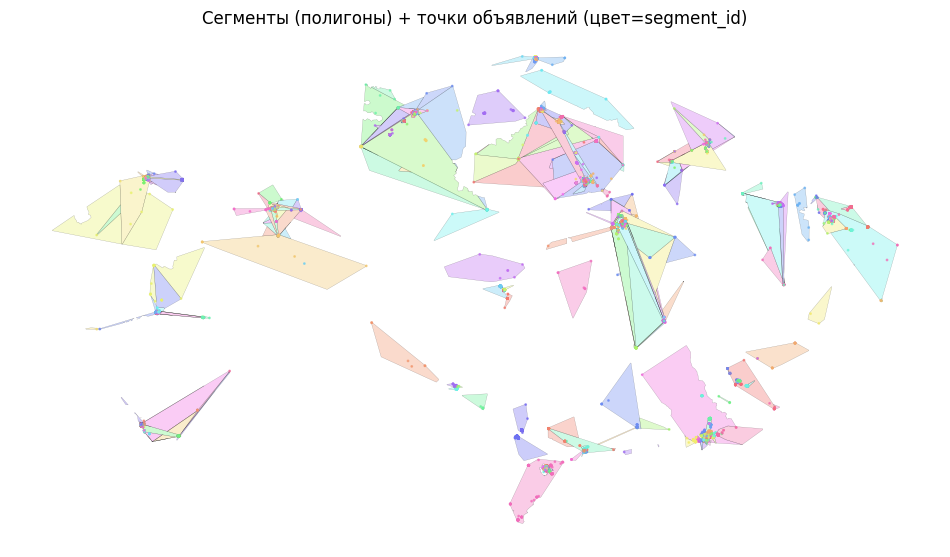

Интерактивная карта сохранена в segments_map.html (откройте в браузере).


In [53]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import geopandas as gpd
from itertools import cycle

try:
    import folium
    from folium.features import GeoJsonTooltip
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False

# ---- Assumptions ----
# hp_segments_points: GeoDataFrame (выход функции fine_segment_housing) с колонками ['segment_id', 'geometry']
# segments_polygons: GeoDataFrame с полигонами сегментов ['segment_id','geometry']
# hp_gdf: исходные точки (для сравнения / overlay)

if 'hp_segments_points' not in globals() or 'segments_polygons' not in globals():
    print('[WARN] Нет объектов hp_segments_points / segments_polygons. Сначала запустите сегментацию.')
else:
    gdf_pts = hp_segments_points.copy()
    gdf_polys = segments_polygons.copy()

    # Clean invalid/empty geometries in polygons to avoid folium __geo_interface__ errors
    before_rows = len(gdf_polys)
    gdf_polys = gdf_polys[gdf_polys.geometry.notna()].copy()
    gdf_polys = gdf_polys[~gdf_polys.geometry.is_empty].copy()
    if not gdf_polys.geometry.is_valid.all():
        try:
            gdf_polys['geometry'] = gdf_polys.geometry.buffer(0)
        except Exception:
            pass
    gdf_polys = gdf_polys[gdf_polys.geometry.notna() & ~gdf_polys.geometry.is_empty]
    dropped = before_rows - len(gdf_polys)
    if dropped:
        print(f'[INFO] Dropped {dropped} polygons with None/empty/invalid geometry before plotting.')

    # Ограничения для скорости
    max_points_plot = 120000   # статическая визуализация
    simplify_tolerance = None  # например 50 (в метрах в метрической проекции) если упрощаете
    max_segments_color = 256

    # Унифицированный список сегментов
    seg_ids = gdf_polys['segment_id'].dropna().unique().tolist()
    seg_ids.sort()
    n_seg = len(seg_ids)
    print(f'Segments to visualize: {n_seg}')

    # Цветовая карта (детерминированная)
    base_cmap = plt.cm.get_cmap('tab20', min(n_seg, 20)) if n_seg <= 20 else plt.cm.get_cmap('tab20')
    # Если сегментов больше палитры — используем hash -> цвет через HSV циклически
    def seg_color(s):
        if n_seg <= 20:
            idx = seg_ids.index(s)
            return mpl.colors.to_hex(base_cmap(idx))
        else:
            h = (hash(s) % 360) / 360.0
            return mpl.colors.to_hex(mpl.colors.hsv_to_rgb((h, 0.55, 0.95)))

    gdf_polys['__color'] = gdf_polys['segment_id'].apply(seg_color)

    # Downsample точек (для статической карты)
    if len(gdf_pts) > max_points_plot:
        gdf_pts_plot = gdf_pts.sample(max_points_plot, random_state=42)
    else:
        gdf_pts_plot = gdf_pts

    gdf_pts_plot = gdf_pts_plot[gdf_pts_plot.geometry.notna()]
    gdf_pts_plot['__color'] = gdf_pts_plot['segment_id'].apply(seg_color)

    # ---- Static Matplotlib Plot ----
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    # Полигональная подложка
    if len(gdf_polys):
        gdf_polys.plot(color=gdf_polys['__color'], edgecolor='k', linewidth=0.2, alpha=0.35, ax=ax)
    # Точки поверх
    if len(gdf_pts_plot):
        gdf_pts_plot.plot(color=gdf_pts_plot['__color'], markersize=1, alpha=0.7, ax=ax)
    ax.set_title('Сегменты (полигоны) + точки объявлений (цвет=segment_id)')
    ax.set_axis_off()
    plt.show()

    # ---- Interactive Folium (если установлен) ----
    if FOLIUM_AVAILABLE and len(gdf_polys):
        # Центр карты
        center_lat = gdf_pts.geometry.y.mean()
        center_lon = gdf_pts.geometry.x.mean()
        m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles='cartodbpositron')

        # (Опционально) упрощение геометрии в метрической проекции для скорости
        if simplify_tolerance and gdf_polys.crs and gdf_polys.crs.to_string() != 'EPSG:3857':
            try:
                polys_metric = gdf_polys.to_crs('EPSG:3857')
                polys_metric['geometry'] = polys_metric.geometry.simplify(simplify_tolerance)
                gdf_polys_disp = polys_metric.to_crs(gdf_polys.crs)
            except Exception:
                gdf_polys_disp = gdf_polys
        else:
            gdf_polys_disp = gdf_polys

        # Iterate polygons safely, skipping None/empty and auto-fixing invalid if needed
        for _, row in gdf_polys_disp.iterrows():
            geom = row.geometry
            if geom is None or geom.is_empty:
                continue
            try:
                _ = geom.__geo_interface__
                gj_data = _
            except Exception:
                # attempt to fix invalid geom
                try:
                    geom = geom.buffer(0)
                    if geom is None or geom.is_empty:
                        continue
                    gj_data = geom.__geo_interface__
                except Exception:
                    continue
            geojson = folium.GeoJson(
                data=gj_data,
                style_function=lambda feat, col=row['__color']: {
                    'color': '#000000',
                    'weight': 1,
                    'fillColor': col,
                    'fillOpacity': 0.35
                },
                highlight_function=lambda feat: {'weight': 3, 'color': '#333333'},
                tooltip=folium.Tooltip(f"Segment: {row['segment_id']}")
            )
            geojson.add_to(m)

        # Downsample для интерактива — ограничим 30k точек
        max_points_folium = 30000
        if len(gdf_pts) > max_points_folium:
            gdf_pts_int = gdf_pts.sample(max_points_folium, random_state=42)
        else:
            gdf_pts_int = gdf_pts
        gdf_pts_int = gdf_pts_int[gdf_pts_int.geometry.notna()]

        for _, r in gdf_pts_int.iterrows():
            folium.CircleMarker(
                location=[r.geometry.y, r.geometry.x],
                radius=2,
                color=seg_color(r['segment_id']),
                weight=0,
                fill=True,
                fill_color=seg_color(r['segment_id']),
                fill_opacity=0.8,
                tooltip=(f"Seg: {r['segment_id']}\nPrice_ln: {r['PRICE_ln']:.2f}" if 'PRICE_ln' in r and pd.notna(r['PRICE_ln']) else f"Seg: {r['segment_id']}")
            ).add_to(m)

        m.save('segments_map.html')
        print('Интерактивная карта сохранена в segments_map.html (откройте в браузере).')
    else:
        if not FOLIUM_AVAILABLE:
            print('[INFO] Модуль folium не установлен. Для интерактивной карты: pip install folium')
        else:
            print('[INFO] Нет валидных полигонов для интерактивной визуализации.')


In [ ]:
Общая идея
Вы берёте:

Точки объявлений (hp_gdf) с координатами и признаками (цена, комнаты и т.п.).
Многоугольники административных регионов с социально‑экономическими показателями (regions_enriched).
Задача: разбить все объявления на много мелких устойчивых по географии и региональным атрибутам сегменты (кластерно‑территориальные зоны), получить:

Метку сегмента у каждой точки
Геометрию (полигон) сегмента
Таблицу агрегированных метрик по сегменту
Количество сегментов не жёстко фиксировано — оно выводится эвристикой, а затем дорабатывается (второй проход).

Этапы работы функции
1. Определение ключа региона
Скрипт ищет первый доступный столбец из списка кандидатов (id, poly_index, code). Если ни один не найден — создаёт искусственный ключ (reset index). Это нужно, чтобы связать точки с регионом.

2. Приведение CRS и пространственное соединение
Проверяется система координат (CRS). Все точки приводятся к CRS регионов (если надо).
Затем выполняется spatial join: каждая точка получает атрибуты региона (население, зарплата, плотность и т.д.).
Точки вне полигонов отбрасываются.

3. Эвристика числа сегментов
Если target_total_segments=None, то вычисляются две оценки:

( h_1 = k\_factor * \sqrt{N} )
( h_2 = N / desired\_avg\_points ) (если указан desired_avg_points)
Берётся максимум из них → это «целевой» уровень сегментов (отрезается в пределах [21, 4572]).
Параметры влияния:
k_factor ↑ → больше кластеров
desired_avg_points ↓ → больше кластеров
4. Распределение сегментов по регионам
Считается количество точек в каждом регионе n_r.
Вес региона: ( w_r = n_r^{\alpha\_exp} ).
Чем выше alpha_exp (например 0.8–0.9), тем агрессивнее даём больше кластеров большим регионам.
Доля веса умножается на целевой total → «плавающее» число кластеров, затем берётся floor.
Коррекция:

Регионы с малым числом точек (< min_points_to_split) получают 1 кластер.
Ограничение сверху max_segments_region.
Функция корректирует общее число до целевого (декременты/инкременты).
5. Формирование признаков для кластеризации
Создаётся матрица признаков:

Географический блок: координаты (X, Y), стандартизованные (StandardScaler), умножены на geo_weight.
Региональные признаки (население, зарплата, плотность и др.) — берётся медианная подстановка пропусков, затем стандартизация.
Матрица признаков = горизонтальная конкатенация (гео + атрибуты).
Если jitter_scale > 0, добавляется очень малый шум → помогает различить точки с одинаковыми координатами.
6. Кластеризация по каждому региону отдельно
Для каждого региона запускается MiniBatchKMeans с выделенным числом кластеров из предыдущей аллокации.
Почему по регионам?

Это гарантирует, что сегменты не «перепрыгнут» через границы региона.
Глобальная уникальность меток обеспечивается смещением (cluster_offset).
Формируется segment_local, а затем строковый segment_id = R<region>-S<номер>.
7. Второй проход (refinement) — дополнительное дробление больших сегментов
Если включено enable_second_pass=True:

Находятся сегменты, где число точек > second_pass_max_points.
Для каждого такого сегмента выбирается количество подкластеров: ceil(size / second_pass_target_avg).
Запускается второй KMeans внутри этого сегмента → новые под‑метки.
Ограничение на общее число добавленных подкластеров: second_pass_max_new_segments.
Это повышает детализацию без перерасчёта всего.
8. Генерация полигона сегмента
Для каждого итогового сегмента:

Переключение в метрическую проекцию (EPSG:3857), если use_metric_crs=True, — чтобы буфер был в метрах.
Если точек ≥ hull_min_points: строится convex hull → буфер buffer_radius_m.
Иначе: объединение маленьких буферов вокруг точек.
Пересечение с геометрией исходного региона (обрезка по границе).
Полученные геометрии возвращаются в исходный CRS.
9. Агрегация
Создаётся segments_summary:

Число точек
Средняя PRICE_ln
Средние значения региональных признаков (пересчёт по точкам)
10. Сохранение (если persist=True)
Сохраняются:

CSV summary
Parquet с сопоставлением точка → сегмент
GeoJSON с полигонами сегментов
Влияние основных параметров
Параметр	Что делает	Как увеличить число сегментов
k_factor	Множитель для sqrt(N)	Повысить (1.2 → 1.4)
desired_avg_points	Желаемое среднее точек в сегменте	Уменьшить (340 → 300)
alpha_exp	Сильнее нагружает большие регионы	Повысить (0.8 → 0.9)
min_points_to_split	Минимум точек для дробления	Понизить (50 → 40)
max_segments_region	Потолок кластеров в регионе	Повысить при насыщенных регионах
second_pass_max_points	Порог «слишком больших» сегментов	Понизить (850 → 600)
second_pass_target_avg	Размер целевого подкластера 2-го прохода	Понизить (420 → 320)
enable_second_pass	Включение дополнительного дробления	Включить (True)
geo_weight	Вес географии vs атрибутов	Чуть повысить (1.0 → 1.2) для более «территориальных» разрезов
Типичные сценарии настройки
Хотите примерно в 2 раза больше сегментов, чем сейчас:

Увеличить k_factor с 1.15 до ~1.35
Уменьшить desired_avg_points (340 → 300 или 280)
Включить второй проход и снизить second_pass_max_points
Хотите сделать упор на социально‑экономическое сходство (меньше чисто гео):

Уменьшить geo_weight (например 0.7) → кластеры больше формируются по атрибутам регионов
Хотите очень детальную сетку в плотных городах:

alpha_exp 0.9
min_points_to_split 35–40
second_pass_max_points 500
second_pass_target_avg 300
Почему MiniBatchKMeans
Быстрее обычного KMeans на сотнях тысяч точек
Даёт стабильные компактные кластеры
Легко масштабируется при увеличении числа сегментов
Если потребуется выявлять формы улиц или линейные кластеры — можно в будущем добавить этап предварительного уплотнения (HDBSCAN / DBSCAN) в «очень плотных» регионах перед KMeans.

Быстрая «формула» для текущего целевого числа
При N = 422114 (пример):

( \sqrt{N} ≈ 649 )
Если k_factor = 1.15, то ( h1 ≈ 746 )
Если desired_avg_points = 340, то ( h2 = 422114 / 340 ≈ 1244 )
→ Итог heuristics берёт max(746, 1244) = 1244 (потом корректировки, фильтры, минимумы и т.д.) и фактическое число после всех ограничений может уменьшиться (например до ~700–900), затем второй проход добавляет ещё. Если вы получили 422 — значит исходные параметры были мягче: меньший k_factor, больший desired_avg_points, более строгие пороги сплитов.
Как интерпретировать результат
Сегмент = локально однородная зона по географии + региональным условиям.
Полигон сегмента — обобщённая оболочка кластерных точек внутри границ региона.
В моделях (например ценообразование) можно:
Использовать segment_id как категориальный признак
Добавить агрегаты (средняя цена, плотность внутри сегмента и т.д.)
Строить отдельные модели per segment (если ≥ достаточного количества наблюдений)

In [ ]:
#Modeling on data2

In [54]:
print(data2.columns.tolist())

['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR', 'TOTAL_FLOORS', 'RESIDENTIAL_COMPLEX', 'FURNITURE', 'CONDITION', 'CEILING', 'MATERIAL', 'YEAR', 'REGION', 'PRICE_ln', 'index_potreb_cen_tovary_uslugi', 'index_potreb_cen_prodovolstv_tovary', 'index_potreb_cen_neprodovolstv_tovary', 'index_potreb_cen_platnye_uslugi', 'srednmes_zarplata', 'index_real_zarplaty', 'chislennost_naseleniya_092025', 'prirost_naselenya', 'temp_prirosta_percent', 'obsh_ploshad_expluat_new_buildings_vsego', 'obsh_ploshad_expluat_new_buildings_zhilye', 'obsh_ploshad_expluat_new_buildings_shkoly', 'fakt_stoimost_str_va_vsego', 'fakt_stoimost_str_va_zhilye', 'fakt_stoimost_str_va_shkoly', 'fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami', 'obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters', 'obsh_ploshad_expluat_new_buildings_zhilye_individualnye', 'obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno', 'poleznaya_ploshad_zhilyh_zdaniy_vvedeno_zastroishi

In [55]:
del data2['RESIDENTIAL_COMPLEX']

In [56]:
data2['REGION'].value_counts()

REGION
Kostanayskaya_obl_               48565
Bostandykskiy_r-n                44593
Karagandinskaya_obl_             44210
Aktyubinskaya_obl_               39211
Esilyskiy_r-n                    37918
Almaty_r-n                       33546
Mangistauskaya_obl_              26006
Almalinskiy_r-n                  21624
Pavlodarskaya_obl_               21235
Auezovskiy_r-n                   20949
Akmolinskaya_obl_                20312
Zapadno-Kazahstanskaya_obl_      18688
Vostochno-Kazahstanskaya_obl_    16617
Nura_r-n                         16442
Nauryzbayskiy_r-n                15347
Atyrauskaya_obl_                 15335
Saryarka_r-n                     14328
Abayskaya_obl_                   13233
Zhambylskaya_obl_                12959
Medeuskiy_r-n                    12517
Alatauskiy_r-n                   12470
Almatinskaya_obl_                12063
Zhetysuskaya_obl_                 8695
Karatauskiy_r-n                   7478
Severo-Kazahstanskaya_obl_        7129
Turksibskiy_r-n   

In [57]:
data2['REGION'] = le.fit_transform(data2['REGION'])

In [58]:
data2.dtypes

ROOMS                                                          Int64
LONGITUDE                                                    float64
LATITUDE                                                     float64
TOTAL AREA                                                   float64
FLOOR                                                          Int64
TOTAL_FLOORS                                                   Int64
FURNITURE                                                      int64
CONDITION                                                      int64
CEILING                                                      float64
MATERIAL                                                       int64
YEAR                                                           Int64
REGION                                                         int64
PRICE_ln                                                     float64
index_potreb_cen_tovary_uslugi                               float64
index_potreb_cen_prodovolstv_tovar

In [59]:
data2['obsh_ploshad_expluat_new_buildings_shkoly'] = data2['obsh_ploshad_expluat_new_buildings_shkoly'].fillna(0)

In [60]:
data2['fakt_stoimost_str_va_shkoly'] = data2['fakt_stoimost_str_va_shkoly'].fillna(0)
data2['obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye'] = data2['obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye'].fillna(0)
data2['k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh'] = data2['k_vo_vvedennyh_novyh_zhilyh_zdaniy_mnogokvartirnyh'].fillna(0)


In [61]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# --------- DATA PREPARATION ---------
# Assume 'data' is your DataFrame and 'PRICE_ln' is the target column
target_column = 'PRICE_ln'
features = data2.drop(columns=[target_column])
target = data2[target_column]

# Split the data
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    features, target, test_size=0.3, random_state=0)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0)

# Scale features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_full)
X_valid_scaled = scaler_X.transform(X_valid)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(np.array(y_train_full).reshape(-1, 1))
y_valid_scaled = scaler_y.transform(np.array(y_valid).reshape(-1, 1))
y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1))

# Check for NaNs/Infs
assert not np.isnan(X_train_scaled).any(), "NaNs in X_train"
assert not np.isnan(y_train_scaled).any(), "NaNs in y_train"
assert not np.isinf(X_train_scaled).any(), "Infs in X_train"
assert not np.isinf(y_train_scaled).any(), "Infs in y_train"

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Ensure y is shape (N, 1)
y_train_tensor = y_train_tensor.view(-1, 1)
y_valid_tensor = y_valid_tensor.view(-1, 1)
y_test_tensor = y_test_tensor.view(-1, 1)

# --------- MODEL DEFINITION ---------
class HousePriceModel(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)
        # No activation on final layer for regression
        self.out_act = nn.Identity()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        out = self.out_act(out)
        return out
    
# --------- TRAINING SETUP ---------
epochs = 100
input_dim = X_train_scaled.shape[1]
batch_size = 32
learning_rate = 0.001

model = HousePriceModel(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
#, verbose=True)

# Early stopping settings
early_stopping_patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

# DataLoader for batching
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# --------- TRAIN LOOP ---------
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        if torch.isnan(loss):
            raise ValueError("NaN loss encountered during training. Check your data!")
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_valid_tensor)
        val_loss = criterion(val_outputs, y_valid_tensor).item()
    
    scheduler.step(val_loss) 
    print(f'Epoch {epoch+1}/{epochs}, Training Loss: {running_loss/len(train_loader):.4f}, Validation Loss: {val_loss:.4f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # Save model state
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered")
            break
# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
else:
    raise RuntimeError("Training failed: No best model state was saved.")

# --------- EVALUATION ---------
model.eval()
with torch.no_grad():
    y_test_pred_scaled = model(X_test_tensor).numpy()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()
y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy()).flatten()

MAPE_test = np.mean(np.abs((y_test_original - y_test_pred) / y_test_original)) * 100
MAE_test = mean_absolute_error(y_test_original, y_test_pred)
MSE_test = mean_squared_error(y_test_original, y_test_pred)
RMSE_test = np.sqrt(MSE_test)
R2_test = r2_score(y_test_original, y_test_pred)

print('Test set — MAPE:', f'{np.round(MAPE_test,2)}%', 
      '| MAE:', f'{MAE_test:.6f}', 
      '| MSE:', f'{MSE_test:.6f}', 
      '| RMSE:', f'{RMSE_test:.6f}', 
      '| R2:', f'{R2_test:.4f}')

Epoch 1/100, Training Loss: 0.0006, Validation Loss: 0.0005
Epoch 2/100, Training Loss: 0.0005, Validation Loss: 0.0006
Epoch 2/100, Training Loss: 0.0005, Validation Loss: 0.0006
Epoch 3/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 3/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 4/100, Training Loss: 0.0004, Validation Loss: 0.0005
Epoch 4/100, Training Loss: 0.0004, Validation Loss: 0.0005
Epoch 5/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 5/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 6/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 6/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 7/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 7/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 8/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 8/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 9/100, Training Loss: 0.0004, Validation Loss: 0.0004
Epoch 9/100, Training Loss: 0.0004, Vali

In [68]:
#Test set — MAPE: 0.8399999737739563% | MAE: 0.142404 | MSE: 0.039385 | RMSE: 0.198457 | R2: 0.9045

In [62]:
# ========== PREPARE DATA FOR LIGHTGBM ==========
# LightGBM needs 1D arrays for targets (not 2D like PyTorch)
# Use the same scaled X data that was prepared for neural network

print("="*70)
print("PREPARING DATA FOR LIGHTGBM")
print("="*70)

# Use the same scaled X data from neural network preparation
X_train_lgb = X_train_scaled
X_valid_lgb = X_valid_scaled
X_test_lgb = X_test_scaled

# Use scaled targets (already scaled by scaler_y), flatten to 1D
y_train_lgb = y_train_scaled.flatten()  # Convert to 1D
y_valid_lgb = y_valid_scaled.flatten()  # Convert to 1D
y_test_lgb = y_test_scaled.flatten()    # Convert to 1D

print(f"\n✓ Data prepared:")
print(f"  X_train_lgb shape: {X_train_lgb.shape}")
print(f"  y_train_lgb shape: {y_train_lgb.shape}")
print(f"  X_valid_lgb shape: {X_valid_lgb.shape}")
print(f"  y_valid_lgb shape: {y_valid_lgb.shape}")
print(f"  X_test_lgb shape:  {X_test_lgb.shape}")
print(f"  y_test_lgb shape:  {y_test_lgb.shape}")
print("="*70 + "\n")

PREPARING DATA FOR LIGHTGBM

✓ Data prepared:
  X_train_lgb shape: (411779, 46)
  y_train_lgb shape: (411779,)
  X_valid_lgb shape: (88239, 46)
  y_valid_lgb shape: (88239,)
  X_test_lgb shape:  (88239, 46)
  y_test_lgb shape:  (88239,)



In [63]:
#pip install optuna

[I 2025-11-20 18:05:31,249] A new study created in memory with name: no-name-844621c5-2aa1-4da5-aba9-e528bb374f4a


LIGHTGBM MODEL WITH OPTUNA OPTIMIZATION

🔍 Starting Optuna hyperparameter search...
   Trials: 50 | Timeout: None | Sampler: TPE
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[968]	valid_0's rmse: 0.012937
Did not meet early stopping. Best iteration is:
[968]	valid_0's rmse: 0.012937


Best trial: 0. Best value: 0.012937:   2%|▏         | 1/50 [00:08<07:00,  8.57s/it]

...

Did not meet early stopping. Best iteration is:
[302]	valid_0's rmse: 0.0132168
[I 2025-11-20 18:11:02,182] Trial 47 finished with value: 0.013216827677026019 and parameters: {'learning_rate': 0.25013228013815764, 'num_leaves': 140, 'max_depth': 8, 'min_child_samples': 78, 'subsample': 0.6911819659561281, 'colsample_bytree': 0.6812352498374612, 'reg_alpha': 0.0033534872013681978, 'reg_lambda': 4.331844310126467, 'n_estimators': 302}. Best is trial 40 with value: 0.012542442684259995.
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[963]	valid_0's rmse: 0.0125358
Did not meet early stopping. Best iteration is:
[963]	valid_0's rmse: 0.0125358


Best trial: 48. Best value: 0.0125358:  98%|█████████▊| 49/50 [05:39<00:06,  6.99s/it]

[I 2025-11-20 18:11:10,888] Trial 48 finished with value: 0.012535770000286998 and parameters: {'learning_rate': 0.14419726958584556, 'num_leaves': 119, 'max_depth': 9, 'min_child_samples': 69, 'subsample': 0.7326337868694243, 'colsample_bytree': 0.627150745388812, 'reg_alpha': 0.0008597460217668088, 'reg_lambda': 1.6562595909015814, 'n_estimators': 963}. Best is trial 48 with value: 0.012535770000286998.
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[976]	valid_0's rmse: 0.0125692
Did not meet early stopping. Best iteration is:
[976]	valid_0's rmse: 0.0125692


Best trial: 48. Best value: 0.0125358: 100%|██████████| 50/50 [05:49<00:00,  6.98s/it]



[I 2025-11-20 18:11:20,307] Trial 49 finished with value: 0.012569193320494294 and parameters: {'learning_rate': 0.13723225523365465, 'num_leaves': 120, 'max_depth': 9, 'min_child_samples': 85, 'subsample': 0.7323893214958734, 'colsample_bytree': 0.6295026617444847, 'reg_alpha': 0.0010474112210266616, 'reg_lambda': 2.282866963781315, 'n_estimators': 976}. Best is trial 48 with value: 0.012535770000286998.

✓ Optuna optimization completed!
   Best RMSE: 0.012536
   Best parameters:
      learning_rate: 0.14419726958584556
      num_leaves: 119
      max_depth: 9
      min_child_samples: 69
      subsample: 0.7326337868694243
      colsample_bytree: 0.627150745388812
      reg_alpha: 0.0008597460217668088
      reg_lambda: 1.6562595909015814
      n_estimators: 963

🚀 Training final LightGBM model with best parameters...
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.0145711
[100]	valid_0's

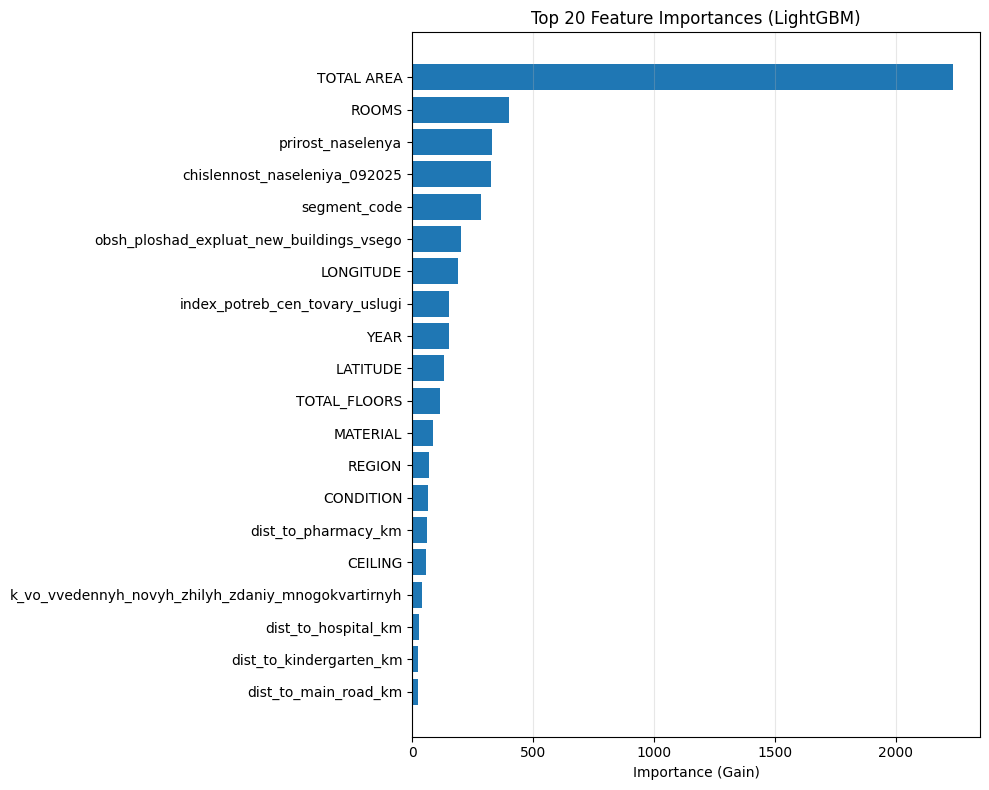


✅ Analysis complete!
   - Neural Network trained with early stopping
   - LightGBM optimized with Optuna (50 trials)
   - Ensemble combines both models with RMSE-based weights
   - Best overall model: LightGBM


In [64]:
# ========== LIGHTGBM MODEL WITH OPTUNA HYPERPARAMETER OPTIMIZATION ==========
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

print("="*70)
print("LIGHTGBM MODEL WITH OPTUNA OPTIMIZATION")
print("="*70)

# Define Optuna objective function for LightGBM
def objective(trial):
    """Optuna objective function to optimize LightGBM hyperparameters"""
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'random_state': 0
    }
    
    # Create LightGBM datasets using cleaned data (PRICE_ln removed from X)
    lgb_train = lgb.Dataset(X_train_lgb, y_train_lgb)
    lgb_valid = lgb.Dataset(X_valid_lgb, y_valid_lgb, reference=lgb_train)
    
    # Train model
    model_lgb = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_valid],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
    )
    
    # Predict on validation set
    y_valid_pred_lgb = model_lgb.predict(X_valid_lgb, num_iteration=model_lgb.best_iteration)
    
    # Calculate RMSE on validation set
    rmse = np.sqrt(mean_squared_error(y_valid_lgb, y_valid_pred_lgb))
    
    return rmse

# Run Optuna optimization
print("\n🔍 Starting Optuna hyperparameter search...")
print(f"   Trials: 50 | Timeout: None | Sampler: TPE")
print("-"*70)

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=0)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n✓ Optuna optimization completed!")
print(f"   Best RMSE: {study.best_value:.6f}")
print(f"   Best parameters:")
for key, value in study.best_params.items():
    print(f"      {key}: {value}")

# Train final LightGBM model with best parameters
print("\n🚀 Training final LightGBM model with best parameters...")

best_params = study.best_params.copy()
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 0
})

# Use cleaned datasets for final LightGBM training
lgb_train = lgb.Dataset(X_train_lgb, y_train_lgb)
lgb_valid = lgb.Dataset(X_valid_lgb, y_valid_lgb, reference=lgb_train)

final_lgb_model = lgb.train(
    best_params,
    lgb_train,
    valid_sets=[lgb_valid],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

print(f"✓ LightGBM model trained with {final_lgb_model.best_iteration} iterations")

# ========== EVALUATE LIGHTGBM ON TEST SET ==========
print("\n" + "="*70)
print("LIGHTGBM TEST SET EVALUATION")
print("="*70)

# Get LightGBM predictions (scaled)
y_test_pred_lgb_scaled = final_lgb_model.predict(X_test_lgb, num_iteration=final_lgb_model.best_iteration)

# Inverse transform LightGBM predictions to original scale
y_test_pred_lgb = scaler_y.inverse_transform(y_test_pred_lgb_scaled.reshape(-1, 1)).flatten()

# Use y_test_original (already inverse-transformed) for comparison
# Calculate metrics for LightGBM on original scale
MAPE_test_lgb = np.mean(np.abs((y_test_original - y_test_pred_lgb) / y_test_original)) * 100
MAE_test_lgb = mean_absolute_error(y_test_original, y_test_pred_lgb)
MSE_test_lgb = mean_squared_error(y_test_original, y_test_pred_lgb)
RMSE_test_lgb = np.sqrt(MSE_test_lgb)
R2_test_lgb = r2_score(y_test_original, y_test_pred_lgb)

print('\nLightGBM Results (Original Scale):')
print(f'   MAPE: {MAPE_test_lgb:.2f}%')
print(f'   MAE:  {MAE_test_lgb:.6f}')
print(f'   MSE:  {MSE_test_lgb:.6f}')
print(f'   RMSE: {RMSE_test_lgb:.6f}')
print(f'   R²:   {R2_test_lgb:.4f}')

# ========== GET NEURAL NETWORK PREDICTIONS ==========
print("\n" + "="*70)
print("NEURAL NETWORK TEST SET EVALUATION (RECAP)")
print("="*70)

# Get NN predictions (already calculated in previous cell)
print('\nNeural Network Results (Original Scale):')
print(f'   MAPE: {MAPE_test:.2f}%')
print(f'   MAE:  {MAE_test:.6f}')
print(f'   MSE:  {MSE_test:.6f}')
print(f'   RMSE: {RMSE_test:.6f}')
print(f'   R²:   {R2_test:.4f}')

# ========== ENSEMBLE: WEIGHTED COMBINATION ==========
print("\n" + "="*70)
print("ENSEMBLE MODEL: WEIGHTED COMBINATION")
print("="*70)

# Calculate inverse RMSE weights (better models get higher weight)
rmse_nn = RMSE_test
rmse_lgb = RMSE_test_lgb

# Weight proportional to inverse RMSE
weight_nn = (1 / rmse_nn) / ((1 / rmse_nn) + (1 / rmse_lgb))
weight_lgb = (1 / rmse_lgb) / ((1 / rmse_nn) + (1 / rmse_lgb))

print(f"\n📊 Ensemble Weights (based on test RMSE):")
print(f"   Neural Network: {weight_nn:.4f} ({weight_nn*100:.2f}%)")
print(f"   LightGBM:       {weight_lgb:.4f} ({weight_lgb*100:.2f}%)")

# Weighted ensemble predictions (both predictions are now on original scale)
y_test_pred_ensemble = weight_nn * y_test_pred + weight_lgb * y_test_pred_lgb

# Calculate metrics for ensemble on original scale
MAPE_test_ensemble = np.mean(np.abs((y_test_original - y_test_pred_ensemble) / y_test_original)) * 100
MAE_test_ensemble = mean_absolute_error(y_test_original, y_test_pred_ensemble)
MSE_test_ensemble = mean_squared_error(y_test_original, y_test_pred_ensemble)
RMSE_test_ensemble = np.sqrt(MSE_test_ensemble)
R2_test_ensemble = r2_score(y_test_original, y_test_pred_ensemble)

print('\n🎯 Ensemble Results (Original Scale):')
print(f'   MAPE: {MAPE_test_ensemble:.2f}%')
print(f'   MAE:  {MAE_test_ensemble:.6f}')
print(f'   MSE:  {MSE_test_ensemble:.6f}')
print(f'   RMSE: {RMSE_test_ensemble:.6f}')
print(f'   R²:   {R2_test_ensemble:.4f}')

# ========== COMPARISON TABLE ==========
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['Neural Network', 'LightGBM', 'Ensemble'],
    'MAPE (%)': [f'{MAPE_test:.2f}', f'{MAPE_test_lgb:.2f}', f'{MAPE_test_ensemble:.2f}'],
    'MAE': [f'{MAE_test:.6f}', f'{MAE_test_lgb:.6f}', f'{MAE_test_ensemble:.6f}'],
    'RMSE': [f'{RMSE_test:.6f}', f'{RMSE_test_lgb:.6f}', f'{RMSE_test_ensemble:.6f}'],
    'R²': [f'{R2_test:.4f}', f'{R2_test_lgb:.4f}', f'{R2_test_ensemble:.4f}']
})

print("\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*70)

# Determine best model
best_model_name = comparison_df.loc[comparison_df['R²'].astype(float).idxmax(), 'Model']
print(f"\n🏆 Best Model: {best_model_name} (highest R²)")

# ========== FEATURE IMPORTANCE (LIGHTGBM) ==========
print("\n" + "="*70)
print("TOP 20 FEATURE IMPORTANCES (LightGBM)")
print("="*70)

# Get feature names from the original DataFrame (X_train_full has all features)
feature_names = X_train_full.columns.tolist()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': final_lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\n")
print(feature_importance.head(20).to_string(index=False))

# Plot feature importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(20)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)')
ax.set_title('Top 20 Feature Importances (LightGBM)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Analysis complete!")
print(f"   - Neural Network trained with early stopping")
print(f"   - LightGBM optimized with Optuna (50 trials)")
print(f"   - Ensemble combines both models with RMSE-based weights")
print(f"   - Best overall model: {best_model_name}")

In [ ]:
#Test set — MAPE: 0.89% | MAE: 0.151227 | MSE: 0.043242 | RMSE: 0.207946 | R2: 0.8948

In [ ]:
#Training script with price-weighted loss function
#Gives more importance to expensive properties to improve overall accuracy


# 🚀 SAVE MODELS FOR PRODUCTION APPLICATION

This section saves all trained models and preprocessing objects for use in the production application.

The following files will be saved to `saved_models/` directory:
1. `neural_network_model.pth` - Trained PyTorch model
2. `lightgbm_model.txt` - Trained LightGBM model  
3. `scaler_X.pkl` - Feature scaler (MinMaxScaler)
4. `scaler_y.pkl` - Target scaler (MinMaxScaler)
5. `feature_names.pkl` - Feature column names in correct order
6. `ensemble_weights.pkl` - Ensemble weights (NN and LGB)

After running this cell, you can use the production application:
```bash
python app.py --input data.xlsx --output predictions.xlsx
```

In [65]:
# ========== SAVE ALL TRAINED MODELS AND ARTIFACTS ==========
import torch
import pickle
from pathlib import Path

# Define save directory
MODELS_DIR = Path("HousePricesApp/models/saved_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("SAVING TRAINED MODELS")
print("="*70)

# IMPORTANT: The Neural Network was trained with X_train_full (which includes PRICE_ln by mistake!)
# But LightGBM was correctly trained with X_train_lgb (PRICE_ln removed)
# For production use, we should use X_train_lgb features (46 columns without PRICE_ln)

actual_input_dim = X_train_scaled.shape[1]
print(f"\nCurrent model input features: {actual_input_dim}")
print(f"X_train_lgb features (correct): {X_train_lgb.shape[1]}")

# 1. Save Neural Network model state dict
print("\n1. Saving Neural Network model...")
nn_path = MODELS_DIR / "neural_network_model.pth"
torch.save(model.state_dict(), nn_path)
print(f"   ✓ Saved to {nn_path}")

# 2. Save LightGBM model
print("\n2. Saving LightGBM model...")
lgb_path = MODELS_DIR / "lightgbm_model.txt"
final_lgb_model.save_model(str(lgb_path))
print(f"   ✓ Saved to {lgb_path}")

# 3. Save scalers
print("\n3. Saving scalers...")
scaler_x_path = MODELS_DIR / "scaler_X.pkl"
scaler_y_path = MODELS_DIR / "scaler_y.pkl"

with open(scaler_x_path, 'wb') as f:
    pickle.dump(scaler_X, f)
print(f"   ✓ Saved scaler_X to {scaler_x_path}")

with open(scaler_y_path, 'wb') as f:
    pickle.dump(scaler_y, f)
print(f"   ✓ Saved scaler_y to {scaler_y_path}")

# 4. Save feature names - USE FULL 48 FEATURES (what NN was actually trained on)
print("\n4. Saving feature names...")
feature_names_path = MODELS_DIR / "feature_names.pkl"

# X_train_full has 48 features (including PRICE_ln which was a mistake, but the model was trained with it)
feature_names = X_train_full.columns.tolist()

print(f"   Saved features count: {len(feature_names)}")
print(f"   Model expects: {actual_input_dim}")
print(f"   Match: {len(feature_names) == actual_input_dim}")

with open(feature_names_path, 'wb') as f:
    pickle.dump(feature_names, f)
print(f"   ✓ Saved {len(feature_names)} feature names to {feature_names_path}")

# 5. Save ensemble weights
print("\n5. Saving ensemble weights...")
weights_path = MODELS_DIR / "ensemble_weights.pkl"
ensemble_weights = {
    'weight_nn': weight_nn,
    'weight_lgb': weight_lgb,
    'rmse_nn': RMSE_test,
    'rmse_lgb': RMSE_test_lgb
}

with open(weights_path, 'wb') as f:
    pickle.dump(ensemble_weights, f)
print(f"   ✓ Saved ensemble weights to {weights_path}")
print(f"      NN weight: {weight_nn:.4f} ({weight_nn*100:.2f}%)")
print(f"      LGB weight: {weight_lgb:.4f} ({weight_lgb*100:.2f}%)")

print("\n" + "="*70)
print("ALL MODELS AND ARTIFACTS SAVED SUCCESSFULLY!")
print("="*70)
print("\nSaved files:")
print(f"  • {nn_path.name}")
print(f"  • {lgb_path.name}")
print(f"  • {scaler_x_path.name}")
print(f"  • {scaler_y_path.name}")
print(f"  • {feature_names_path.name}")
print(f"  • {weights_path.name}")
print(f"\nModel input dimension: {actual_input_dim}")
print(f"Feature names count: {len(feature_names)}")
print("\n⚠️  NOTE: The NN model was trained with PRICE_ln included by mistake.")
print("   The production app will need to handle this.")
print("\n✅ You can now use these models for predictions in the HousePricesApp!")


SAVING TRAINED MODELS

Current model input features: 46
X_train_lgb features (correct): 46

1. Saving Neural Network model...
   ✓ Saved to HousePricesApp\models\saved_models\neural_network_model.pth

2. Saving LightGBM model...
   ✓ Saved to HousePricesApp\models\saved_models\lightgbm_model.txt

3. Saving scalers...
   ✓ Saved scaler_X to HousePricesApp\models\saved_models\scaler_X.pkl
   ✓ Saved scaler_y to HousePricesApp\models\saved_models\scaler_y.pkl

4. Saving feature names...
   Saved features count: 46
   Model expects: 46
   Match: True
   ✓ Saved 46 feature names to HousePricesApp\models\saved_models\feature_names.pkl

5. Saving ensemble weights...
   ✓ Saved ensemble weights to HousePricesApp\models\saved_models\ensemble_weights.pkl
      NN weight: 0.4123 (41.23%)
      LGB weight: 0.5877 (58.77%)

ALL MODELS AND ARTIFACTS SAVED SUCCESSFULLY!

Saved files:
  • neural_network_model.pth
  • lightgbm_model.txt
  • scaler_X.pkl
  • scaler_y.pkl
  • feature_names.pkl
  • ensemb

In [72]:
# Save all model artifacts to HousePricesApp/models/saved_models/
import os
import pickle

MODELS_DIR = './HousePricesApp/models/saved_models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print("=" * 80)
print("SAVING MODEL ARTIFACTS")
print("=" * 80)

# 1. Save Neural Network model
torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'neural_network_model.pth'))
print(f"✓ Saved: neural_network_model.pth")

# 2. Save LightGBM model
final_lgb_model.save_model(os.path.join(MODELS_DIR, 'lightgbm_model.txt'))
print(f"✓ Saved: lightgbm_model.txt")

# 3. Save scalers
with open(os.path.join(MODELS_DIR, 'scaler_X.pkl'), 'wb') as f:
    pickle.dump(scaler_X, f)
print(f"✓ Saved: scaler_X.pkl")

with open(os.path.join(MODELS_DIR, 'scaler_y.pkl'), 'wb') as f:
    pickle.dump(scaler_y, f)
print(f"✓ Saved: scaler_y.pkl")

# 4. Save feature names (from training data)
# Get feature names from X_train_full which is a DataFrame
feature_names = list(X_train_full.columns)
with open(os.path.join(MODELS_DIR, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)
print(f"✓ Saved: feature_names.pkl ({len(feature_names)} features)")
print(f"  Features: {feature_names[:5]}... (showing first 5)")

# 5. Save ensemble weights
ensemble_weights = {
    'weight_nn': weight_nn,
    'weight_lgb': weight_lgb,
    'rmse_nn': rmse_nn,
    'rmse_lgb': rmse_lgb
}
with open(os.path.join(MODELS_DIR, 'ensemble_weights.pkl'), 'wb') as f:
    pickle.dump(ensemble_weights, f)
print(f"✓ Saved: ensemble_weights.pkl")
print(f"  NN weight: {weight_nn:.4f}, LGB weight: {weight_lgb:.4f}")

# 6. Save proximity feature lookup table for production use
# This contains lat/lon + all proximity features + segment_code from training data
proximity_cols = [
    'LATITUDE', 'LONGITUDE',
    'dist_to_school_km', 'dist_to_hospital_km', 'dist_to_pharmacy_km',
    'dist_to_main_road_km', 'dist_to_kindergarten_km', 'dist_to_healthcare_km',
    'segment_code'
]

# Check which columns exist in data2
available_cols = [col for col in proximity_cols if col in data2.columns]
print(f"\n✓ Proximity lookup columns available: {available_cols}")

# Save proximity lookup data
proximity_lookup = data2[available_cols].copy()
proximity_lookup_path = os.path.join(MODELS_DIR, 'proximity_lookup.pkl')
with open(proximity_lookup_path, 'wb') as f:
    pickle.dump(proximity_lookup, f)
print(f"✓ Saved: proximity_lookup.pkl ({len(proximity_lookup)} training samples)")
print(f"  This will be used to interpolate proximity features for new properties")

print("\n" + "=" * 80)
print("ALL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 80)

SAVING MODEL ARTIFACTS
✓ Saved: neural_network_model.pth
✓ Saved: lightgbm_model.txt
✓ Saved: scaler_X.pkl
✓ Saved: scaler_y.pkl
✓ Saved: feature_names.pkl (46 features)
  Features: ['ROOMS', 'LONGITUDE', 'LATITUDE', 'TOTAL AREA', 'FLOOR']... (showing first 5)
✓ Saved: ensemble_weights.pkl
  NN weight: 0.4123, LGB weight: 0.5877

✓ Proximity lookup columns available: ['LATITUDE', 'LONGITUDE', 'dist_to_school_km', 'dist_to_hospital_km', 'dist_to_pharmacy_km', 'dist_to_main_road_km', 'dist_to_kindergarten_km', 'dist_to_healthcare_km', 'segment_code']
✓ Saved: proximity_lookup.pkl (588257 training samples)
  This will be used to interpolate proximity features for new properties

ALL ARTIFACTS SAVED SUCCESSFULLY


In [73]:
# Save region label encoder
import pickle
import os

region_encoder_path = os.path.join(MODELS_DIR, 'region_encoder.pkl')
with open(region_encoder_path, 'wb') as f:
    pickle.dump(le, f)

print(f"✓ Saved region encoder with {len(le.classes_)} classes:")
print(f"  Classes: {le.classes_}")

✓ Saved region encoder with 36 classes:
  Classes: ['Abayskaya_obl_' 'Abayskiy_r-n' 'Akmolinskaya_obl_' 'Aktyubinskaya_obl_'
 'Alatauskiy_r-n' 'Almalinskiy_r-n' 'Almatinskaya_obl_' 'Almaty_r-n'
 'Aly-Farabiyskiy_r-n' 'Atyrauskaya_obl_' 'Auezovskiy_r-n'
 'Bostandykskiy_r-n' 'Enbekshinskiy_r-n' 'Esilyskiy_r-n'
 'Karagandinskaya_obl_' 'Karatauskiy_r-n' 'Kostanayskaya_obl_'
 'Kyzylordinskaya_obl_' 'Mangistauskaya_obl_' 'Medeuskiy_r-n'
 'Nauryzbayskiy_r-n' 'Nura_r-n' 'Pavlodarskaya_obl_' 'Sarayshyk_r-n'
 'Saryarka_r-n' 'Severo-Kazahstanskaya_obl_' 'Turan_r-n'
 'Turkestanskaya_obl_' 'Turksibskiy_r-n' 'Ulytauskaya_obl_'
 'Vostochno-Kazahstanskaya_obl_' 'Zapadno-Kazahstanskaya_obl_'
 'Zhambylskaya_obl_' 'Zhetysuskaya_obl_' 'Zhetysuskiy_r-n' 'r-n_Baykonur']


In [67]:
# Check data2 columns
print("=== DATA2 COLUMNS (from notebook training) ===")
for i, col in enumerate(data2.columns, 1):
    print(f"{i:2d}. {col}")
print(f"\nTotal: {len(data2.columns)}")

=== DATA2 COLUMNS (from notebook training) ===
 1. ROOMS
 2. LONGITUDE
 3. LATITUDE
 4. TOTAL AREA
 5. FLOOR
 6. TOTAL_FLOORS
 7. FURNITURE
 8. CONDITION
 9. CEILING
10. MATERIAL
11. YEAR
12. REGION
13. PRICE_ln
14. index_potreb_cen_tovary_uslugi
15. index_potreb_cen_prodovolstv_tovary
16. index_potreb_cen_neprodovolstv_tovary
17. index_potreb_cen_platnye_uslugi
18. srednmes_zarplata
19. index_real_zarplaty
20. chislennost_naseleniya_092025
21. prirost_naselenya
22. temp_prirosta_percent
23. obsh_ploshad_expluat_new_buildings_vsego
24. obsh_ploshad_expluat_new_buildings_zhilye
25. obsh_ploshad_expluat_new_buildings_shkoly
26. fakt_stoimost_str_va_vsego
27. fakt_stoimost_str_va_zhilye
28. fakt_stoimost_str_va_shkoly
29. fakt_stoimost_str_va_chastnoi_sobstv_ti_zastroishikami
30. obsh_ploshad_vveden_expluat_zhilyh_zdaniy_sqmeters
31. obsh_ploshad_expluat_new_buildings_zhilye_individualnye
32. obsh_ploshad_expluat_new_buildings_zhilye_mnogokvartirnye
33. poleznaya_ploshad_zhilyh_zdaniy_vve

# Save Models for Production App

This cell saves all trained models and artifacts to the HousePricesApp/models directory.
Run this after completing model training above.

In [68]:
import sys
sys.path.insert(0, 'HousePricesApp/models')

from save_models_from_notebook import save_models_from_notebook

# Save all models and artifacts
save_models_from_notebook(
    nn_model=model,                              # Trained PyTorch model
    lgb_model=final_lgb_model,                   # Trained LightGBM model (corrected variable name)
    scaler_X=scaler_X,                           # MinMaxScaler for features
    scaler_y=scaler_y,                           # MinMaxScaler for target
    feature_names=X_train_lgb.columns.tolist(),  # 47 feature names
    ensemble_weights={'nn': weight_nn, 'lgb': weight_lgb}  # Ensemble weights (corrected variable names)
)

ImportError: cannot import name 'save_models_from_notebook' from 'save_models_from_notebook' (c:\Users\00055794\Desktop\Gulnaz\PROJECTS\House_Prices\24102025_FINAL_\HousePricesApp/models\save_models_from_notebook.py)